In [54]:
from collections import defaultdict
import pandas as pd
from pandas import DataFrame
import numpy as np

def parse_log_and_extract_performance_metrics(log_file_path):
    """
    Parse the log file and extract performance metrics.
    
    Args:
        log_file_path (str): The path to the log file.
        
    Returns:
        dict: A dictionary containing the performance metrics.
    """
    # Elapsed time: 1038.92 seconds
    # Num requests: 200
    # Throughput: 0.19 requests/s, 2037.93 total tokens/s, 98.56 output tokens/s
    # Total num prompt tokens:  2014849
    # Total num output tokens:  102400
    # Total num tokens: 2117249

    performance_metrics = {}
    with open(log_file_path, 'r') as file:
        for line in file:
            line = line.strip()
            if 'Elapsed time:' in line:
                performance_metrics['e2e_elapsed_time_s'] = float(line.split()[2])
            elif 'Num requests:' in line:
                performance_metrics['num_requests'] = int(line.split()[-1])
            elif 'Throughput:' in line:
                performance_metrics['throughput_reqs_per_s'] = float(line.split()[1])
                performance_metrics['throughput_tok_per_s'] = float(line.split()[3])
            elif 'Total num tokens:' in line:
                performance_metrics['total_tokens'] = int(line.split()[-1])

    return performance_metrics

def convert_datasetmetrics_to_df(dataset_metics):
    ## flatten all runs
    rows = []
    for gpu, ctx_map in dataset_metics.items():
        for context_len, run_metrics in ctx_map.items():
            if isinstance(run_metrics, dict):
                run_metrics = [run_metrics]
                
            for i, metrics in enumerate(run_metrics):
                rows.append({'gpu': gpu, 'context_len': context_len, **metrics})

    df_runs = pd.DataFrame(rows)

    # Average across runs (numeric columns only)
    metric_cols = (
        df_runs.select_dtypes(include=np.number)
               .columns.difference(['run', 'context_len'])
    )

    df_avg = (
        df_runs
        .groupby(['gpu', 'context_len'], as_index=False)[metric_cols]
        .mean()
    )

    return df_avg


def get_throughput_df(base_dir, strategy, dataset, context_lens):
    dataset_metics = defaultdict(lambda: defaultdict(list))
    for try_idx in range(1, 4):
        for context_len in context_lens:
            if dataset == "sharegpt_offline" or dataset == "burstgpt_offline":
                log_file_path = f"{base_dir}/{strategy}/logs_v1_Llama-3.1-8B_ofd0/{dataset}/offline_c32768_r5000_tp1_pp1_gpu0.9_bt{context_len}_{try_idx}_.log"
            elif dataset == "azureconv_offline":
                log_file_path = f"{base_dir}/{strategy}/logs_v1_Llama-3.1-8B_ofd0/{dataset}/offline_c32768_r10000_tp1_pp1_gpu0.9_bt{context_len}_{try_idx}_.log"
            elif dataset == "longbench--narrativeqa_offline":
                log_file_path = f"{base_dir}/{strategy}/logs_v1_Llama-3.1-8B_ofd0/{dataset}/offline_c32768_g128_r200_tp1_pp1_gpu0.9_bt{context_len}_{try_idx}_.log"
            else:
                log_file_path = f"{base_dir}/{strategy}/logs_v1_Llama-3.1-8B_ofd0/{dataset}/offline_c32768_g512_r200_tp1_pp1_gpu0.9_bt{context_len}_{try_idx}_.log"

            peformance_metrics = parse_log_and_extract_performance_metrics(log_file_path)
            dataset_metics["gpu=0.9"][context_len].append(peformance_metrics)

    df = convert_datasetmetrics_to_df(dataset_metics)

    return df


def get_avg_latency_df(base_dir, strategy, dataset, context_lens):
    strategies = {
        "default": "default",
        "evict-optimal-7": "opt7",
        # "kv-usage-aware": "kv-aware",
        # "kv-usage-aware-1": "kv-aware-1",
    }

    rows = []
    
    for context_len in context_lens:
        avg_latency_lists = defaultdict(list)
        for try_idx in range(1, 4):
            if dataset == "sharegpt_offline" or dataset == "burstgpt_offline":
                reqs_csv_file_path = f"{base_dir}/{strategy}/logs_v1_Llama-3.1-8B_ofd0/{dataset}/{strategies[strategy]}_c32768_g-1_r5000_gp0.9_bt{context_len}_{try_idx}_req_stats.csv"
            elif dataset == "azureconv_offline":
                reqs_csv_file_path = f"{base_dir}/{strategy}/logs_v1_Llama-3.1-8B_ofd0/{dataset}/{strategies[strategy]}_c32768_g-1_r10000_gp0.9_bt{context_len}_{try_idx}_req_stats.csv"
            elif dataset == "longbench--narrativeqa_offline":
                reqs_csv_file_path = f"{base_dir}/{strategy}/logs_v1_Llama-3.1-8B_ofd0/{dataset}/{strategies[strategy]}_c32768_g128_r200_gp0.9_bt{context_len}_{try_idx}_req_stats.csv"
            else:   
                reqs_csv_file_path = f"{base_dir}/{strategy}/logs_v1_Llama-3.1-8B_ofd0/{dataset}/{strategies[strategy]}_c32768_g512_r200_gp0.9_bt{context_len}_{try_idx}_req_stats.csv"

            df = pd.read_csv(reqs_csv_file_path)
            avg_latency_lists["e2e_latency_ms"].append(df["e2e_latency_ms"].mean())
            avg_latency_lists["queued_time_ms"].append(df["queued_time_ms"].mean())
            avg_latency_lists["prefill_time_ms"].append(df["prefill_time_ms"].mean())
            avg_latency_lists["decode_time_ms"].append(df["decode_time_ms"].mean())
            avg_latency_lists["inference_time_ms"].append(df["inference_time_ms"].mean())
            avg_latency_lists["ttft_latency_ms"].append(df["ttft_latency_ms"].mean())
            avg_latency_lists["tpot_latency_ms"].append(df["tpot_latency_ms"].mean())
            avg_latency_lists["tpot_latency_ms_median"].append(df["tpot_latency_ms"].median())
            avg_latency_lists["tpot_latency_ms_std"].append(df["tpot_latency_ms"].std(ddof=0))
            avg_latency_lists["tpot_latency_ms_p90"].append(df["tpot_latency_ms"].quantile(0.9))
            avg_latency_lists["tpot_latency_ms_p95"].append(df["tpot_latency_ms"].quantile(0.95))
            avg_latency_lists["tpot_latency_ms_p99"].append(df["tpot_latency_ms"].quantile(0.99))
            avg_latency_lists["tpot_latency_ms_p99.9"].append(df["tpot_latency_ms"].quantile(0.999))

        row = {
            "gpu": "gpu=0.9",
            "context_len": context_len,
            "e2e_latency_ms": sum(avg_latency_lists["e2e_latency_ms"]) / len(avg_latency_lists["e2e_latency_ms"]),
            "queued_time_ms": sum(avg_latency_lists["queued_time_ms"]) / len(avg_latency_lists["queued_time_ms"]),
            "prefill_time_ms": sum(avg_latency_lists["prefill_time_ms"]) / len(avg_latency_lists["prefill_time_ms"]),
            "decode_time_ms": sum(avg_latency_lists["decode_time_ms"]) / len(avg_latency_lists["decode_time_ms"]),
            "inference_time_ms": sum(avg_latency_lists["inference_time_ms"]) / len(avg_latency_lists["inference_time_ms"]),
            "ttft_latency_ms": sum(avg_latency_lists["ttft_latency_ms"]) / len(avg_latency_lists["ttft_latency_ms"]),
            "tpot_latency_ms": sum(avg_latency_lists["tpot_latency_ms"]) / len(avg_latency_lists["tpot_latency_ms"]),
            "tpot_latency_ms_median": sum(avg_latency_lists["tpot_latency_ms_median"]) / len(avg_latency_lists["tpot_latency_ms_median"]),
            "tpot_latency_ms_std": sum(avg_latency_lists["tpot_latency_ms_std"]) / len(avg_latency_lists["tpot_latency_ms_std"]),
            "tpot_latency_ms_p90": sum(avg_latency_lists["tpot_latency_ms_p90"]) / len(avg_latency_lists["tpot_latency_ms_p90"]),
            "tpot_latency_ms_p95": sum(avg_latency_lists["tpot_latency_ms_p95"]) / len(avg_latency_lists["tpot_latency_ms_p95"]),
            "tpot_latency_ms_p99": sum(avg_latency_lists["tpot_latency_ms_p99"]) / len(avg_latency_lists["tpot_latency_ms_p99"]),
            "tpot_latency_ms_p99.9": sum(avg_latency_lists["tpot_latency_ms_p99.9"]) / len(avg_latency_lists["tpot_latency_ms_p99.9"]),
        }
        rows.append(row)

    return pd.DataFrame(rows)


def get_avg_recomputations_df(base_dir, strategy, dataset, context_lens):
    strategies = {
        "default": "default",
        "evict-optimal-7": "opt7",
        # "kv-usage-aware": "kv-aware",
        # "kv-usage-aware-1": "kv-aware-1",
    }

    rows = []
    
    for context_len in context_lens:
        total_reqs_per_run = []
        total_tokens_per_run = []
        for try_idx in range(1, 4):
            if dataset == "sharegpt_offline" or dataset == "burstgpt_offline":
                reqs_csv_file_path = f"{base_dir}/{strategy}/logs_v1_Llama-3.1-8B_ofd0/{dataset}/{strategies[strategy]}_c32768_g-1_r5000_gp0.9_bt{context_len}_{try_idx}_sched_stats.csv"
            elif dataset == "azureconv_offline":
                reqs_csv_file_path = f"{base_dir}/{strategy}/logs_v1_Llama-3.1-8B_ofd0/{dataset}/{strategies[strategy]}_c32768_g-1_r10000_gp0.9_bt{context_len}_{try_idx}_sched_stats.csv"
            elif dataset == "longbench--narrativeqa_offline":
                reqs_csv_file_path = f"{base_dir}/{strategy}/logs_v1_Llama-3.1-8B_ofd0/{dataset}/{strategies[strategy]}_c32768_g128_r200_gp0.9_bt{context_len}_{try_idx}_sched_stats.csv"
            else:   
                reqs_csv_file_path = f"{base_dir}/{strategy}/logs_v1_Llama-3.1-8B_ofd0/{dataset}/{strategies[strategy]}_c32768_g512_r200_gp0.9_bt{context_len}_{try_idx}_sched_stats.csv"

            df = pd.read_csv(reqs_csv_file_path)

            # Sum recomputation events per run (across steps)
            if "num_preempted_requests" in df.columns:
                total_reqs = pd.to_numeric(df["num_preempted_requests"], errors="coerce").fillna(0).sum()
            else:
                total_reqs = 0

            if "total_preempted_tokens" in df.columns:
                total_tokens = pd.to_numeric(df["total_preempted_tokens"], errors="coerce").fillna(0).sum()
            else:
                total_tokens = 0

            total_reqs_per_run.append(total_reqs)
            total_tokens_per_run.append(total_tokens)

        # Average totals across runs and also report overall totals across runs
        row = {
            "gpu": "gpu=0.9",
            "context_len": context_len,
            "avg_recmp_reqs": float(np.mean(total_reqs_per_run)) if total_reqs_per_run else 0.0,
            "avg_recmp_tokens": float(np.mean(total_tokens_per_run)) if total_tokens_per_run else 0.0,
        }
        rows.append(row)

    return pd.DataFrame(rows)

    

In [55]:
def plot_throughput_vs_context_length(dataset_name, context_lens, my_df):
    import matplotlib.pyplot as plt

    strategies = [
    ("default", "default"),
    ("opt7", "opt7"),
    # ("kv-aware", "kv-aware"),
    # ("kv-aware-1", "kv-aware-1"),
    ]

    # Treat x-axis as categorical: equal spacing with string tick labels
    x_vals = list(context_lens)
    x_labels = [str(x) for x in x_vals]
    x_pos = {v: i for i, v in enumerate(x_vals)}

    plt.figure(figsize=(8, 5))
    for key, label in strategies:
        df = my_df[key][dataset_name].copy()
        if df.empty:
            continue
        df = df.sort_values("context_len")
        x = df["context_len"].map(x_pos)
        y = df["throughput_tok_per_s"]
        plt.plot(
            x,
            y,
            marker="o",
            linewidth=2,
            label=label,
        )

    plt.xlabel("Context length")
    plt.ylabel("Throughput (tokens/s)")
    plt.title(f"{dataset_name}: Throughput vs Context length")
    plt.legend(title="Strategy")
    plt.grid(True, linestyle=":", alpha=0.6)

    # Set categorical ticks with equal spacing
    ax = plt.gca()
    ax.set_xticks(range(len(x_vals)))
    ax.set_xticklabels(x_labels)
    ax.set_ylim(bottom=0)

    plt.tight_layout()
    plt.show()

def plot_latency_vs_context_length(dataset_name, context_lens, my_df):
    import matplotlib.pyplot as plt

    strategies = [
        ("default", "default"),
        ("opt7", "opt7"),
        # ("kv-aware", "kv-aware"),
        # ("kv-aware-1", "kv-aware-1"),
    ]

    # Treat x-axis as categorical: equal spacing with string tick labels
    x_vals = list(context_lens)
    x_labels = [str(x) for x in x_vals]
    x_pos = {v: i for i, v in enumerate(x_vals)}

    plt.figure(figsize=(8, 5))
    for key, label in strategies:
        print(key, label)
        df = my_df[key][dataset_name].copy()
        if df.empty:
            continue
        df = df.sort_values("context_len")
        x = df["context_len"].map(x_pos)
        y = df["tpot_latency_ms"]
        plt.plot(
            x,
            y,
            marker="o",
            linewidth=2,
            label=label,
        )

    plt.xlabel("Context length")
    plt.ylabel("Latency (ms)")
    plt.title(f"{dataset_name}: Latency vs Context length")
    plt.legend(title="Strategy")
    plt.grid(True, linestyle=":", alpha=0.6)

    # Set categorical ticks with equal spacing
    ax = plt.gca()
    ax.set_xticks(range(len(x_vals)))
    ax.set_xticklabels(x_labels)
    ax.set_ylim(bottom=0)

    plt.tight_layout()
    plt.show()

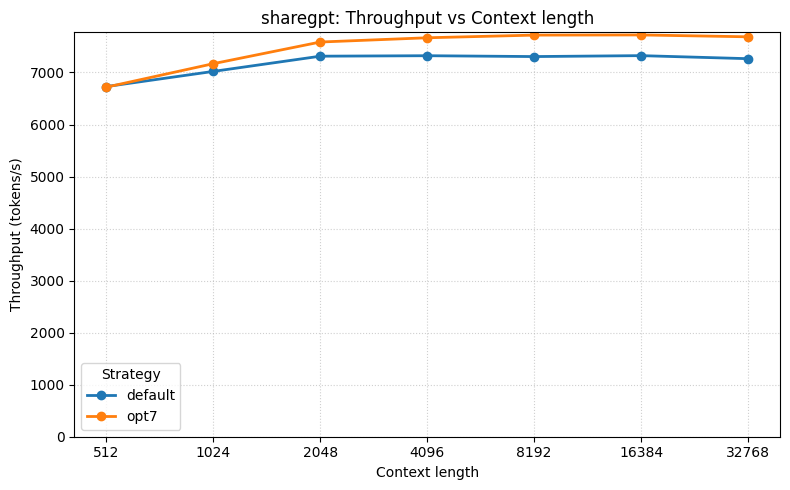

In [56]:
#### ShareGPT Dataset
base_dir = "/Users/yejie/Projects/SCS_Lab/IPDPS25_Scheduling/eval_results/ipdps25_sched/venilla_baseline_v0_8_4/"
# 1) Collect multiple runs for default config
my_df = defaultdict(lambda: defaultdict(DataFrame))
context_lens=(512, 1024, 2048, 4096, 8192, 16384, 32768)
strategy = "default"
dataset = "sharegpt_offline"
df_default_sharegpt = get_throughput_df(base_dir, strategy, dataset, context_lens)
my_df["default"]["sharegpt"] = df_default_sharegpt

strategy = "evict-optimal-7"
dataset = "sharegpt_offline"
df_opt7_sharegpt = get_throughput_df(base_dir, strategy, dataset, context_lens)
my_df["opt7"]["sharegpt"] = df_opt7_sharegpt

# strategy = "kv-usage-aware"
# dataset = "sharegpt_offline"
# df_kvusage_sharegpt = get_throughput_df(base_dir, strategy, dataset, context_lens)
# my_df["kv-aware"]["sharegpt"] = df_kvusage_sharegpt

# strategy = "kv-usage-aware-1"
# dataset = "sharegpt_offline"
# df_kvusage_1_sharegpt = get_throughput_df(base_dir, strategy, dataset, context_lens)
# my_df["kv-aware-1"]["sharegpt"] = df_kvusage_1_sharegpt


# print(my_df["kv-aware-1"]["sharegpt"]["throughput_tok_per_s"])

plot_throughput_vs_context_length("sharegpt", context_lens, my_df)

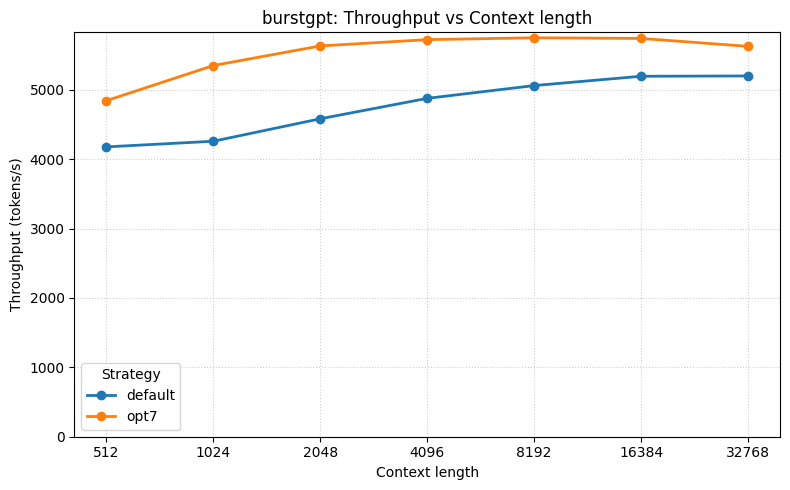

In [57]:
#### BurstGPT Dataset
base_dir = "/Users/yejie/Projects/SCS_Lab/IPDPS25_Scheduling/eval_results/ipdps25_sched/venilla_baseline_v0_8_4/"
# 1) Collect multiple runs for default config
my_df = defaultdict(lambda: defaultdict(DataFrame))
context_lens=(512, 1024, 2048, 4096, 8192, 16384, 32768)
strategy = "default"
dataset = "burstgpt_offline"
df_default_burstgpt = get_throughput_df(base_dir, strategy, dataset, context_lens)
my_df["default"]["burstgpt"] = df_default_burstgpt

strategy = "evict-optimal-7"
dataset = "burstgpt_offline"
df_opt7_burstgpt = get_throughput_df(base_dir, strategy, dataset, context_lens)
my_df["opt7"]["burstgpt"] = df_opt7_burstgpt

# strategy = "kv-usage-aware"
# dataset = "burstgpt_offline"
# df_kvusage_burstgpt = get_throughput_df(base_dir, strategy, dataset, context_lens)
# my_df["kv-aware"]["burstgpt"] = df_kvusage_burstgpt

# strategy = "kv-usage-aware-1"
# dataset = "burstgpt_offline"
# df_kvusage_1_burstgpt = get_throughput_df(base_dir, strategy, dataset, context_lens)
# my_df["kv-aware-1"]["burstgpt"] = df_kvusage_1_burstgpt


# print(my_df["kv-aware-1"]["busrtgpt"]["throughput_tok_per_s"])

plot_throughput_vs_context_length("burstgpt", context_lens, my_df)

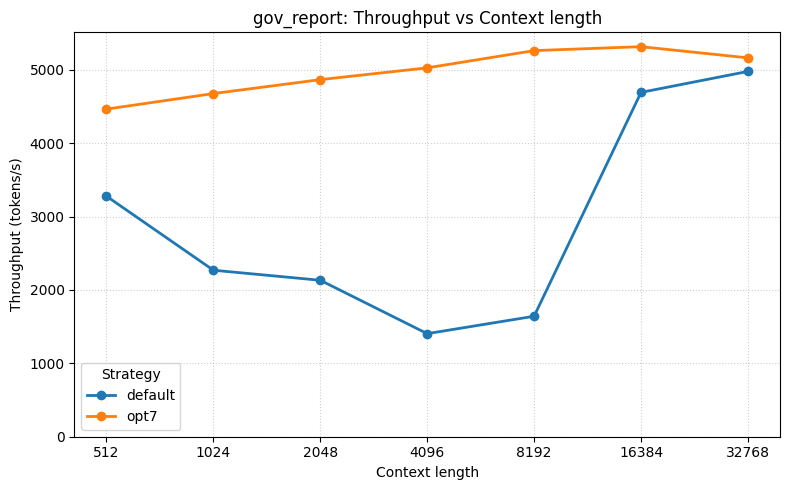

In [58]:
#### BurstGPT Dataset
base_dir = "/Users/yejie/Projects/SCS_Lab/IPDPS25_Scheduling/eval_results/ipdps25_sched/venilla_baseline_v0_8_4/"
# 1) Collect multiple runs for default config
my_df = defaultdict(lambda: defaultdict(DataFrame))
context_lens=(512, 1024, 2048, 4096, 8192, 16384, 32768)
strategy = "default"
dataset = "longbench--gov_report_offline"
df_default_burstgpt = get_throughput_df(base_dir, strategy, dataset, context_lens)
my_df["default"]["gov_report"] = df_default_burstgpt

strategy = "evict-optimal-7"
dataset = "longbench--gov_report_offline"
df_opt7_burstgpt = get_throughput_df(base_dir, strategy, dataset, context_lens)
my_df["opt7"]["gov_report"] = df_opt7_burstgpt

# strategy = "kv-usage-aware"
# dataset = "longbench--gov_report_offline"
# df_kvusage_burstgpt = get_throughput_df(base_dir, strategy, dataset, context_lens)
# my_df["kv-aware"]["gov_report"] = df_kvusage_burstgpt

# strategy = "kv-usage-aware-1"
# dataset = "longbench--gov_report_offline"
# df_kvusage_1_burstgpt = get_throughput_df(base_dir, strategy, dataset, context_lens)
# my_df["kv-aware-1"]["gov_report"] = df_kvusage_1_burstgpt


# print(my_df["kv-aware-1"]["busrtgpt"]["throughput_tok_per_s"])

plot_throughput_vs_context_length("gov_report", context_lens, my_df)

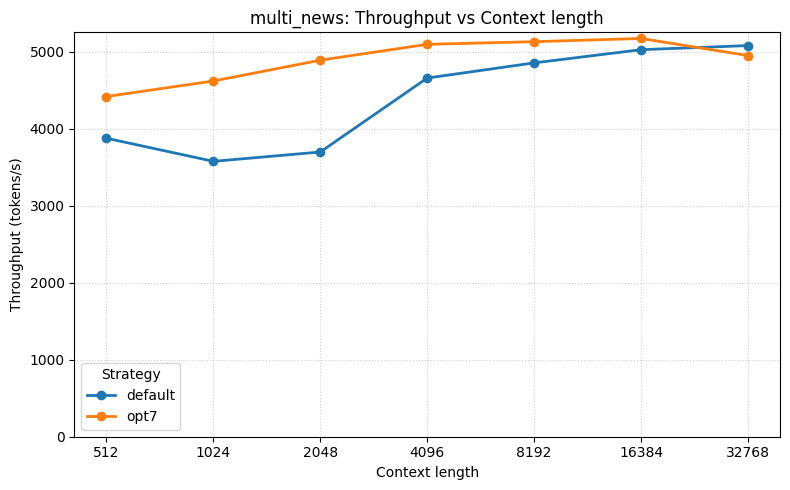

In [59]:
#### BurstGPT Dataset
base_dir = "/Users/yejie/Projects/SCS_Lab/IPDPS25_Scheduling/eval_results/ipdps25_sched/venilla_baseline_v0_8_4/"
# 1) Collect multiple runs for default config
my_df = defaultdict(lambda: defaultdict(DataFrame))
context_lens=(512, 1024, 2048, 4096, 8192, 16384, 32768)
strategy = "default"
dataset = "longbench--multi_news_offline"
df_default_burstgpt = get_throughput_df(base_dir, strategy, dataset, context_lens)
my_df["default"]["multi_news"] = df_default_burstgpt

strategy = "evict-optimal-7"
dataset = "longbench--multi_news_offline"
df_opt7_burstgpt = get_throughput_df(base_dir, strategy, dataset, context_lens)
my_df["opt7"]["multi_news"] = df_opt7_burstgpt

# strategy = "kv-usage-aware"
# dataset = "longbench--multi_news_offline"
# df_kvusage_burstgpt = get_throughput_df(base_dir, strategy, dataset, context_lens)
# my_df["kv-aware"]["multi_news"] = df_kvusage_burstgpt

# strategy = "kv-usage-aware-1"
# dataset = "longbench--multi_news_offline"
# df_kvusage_1_burstgpt = get_throughput_df(base_dir, strategy, dataset, context_lens)
# my_df["kv-aware-1"]["multi_news"] = df_kvusage_1_burstgpt


# print(my_df["kv-aware-1"]["busrtgpt"]["throughput_tok_per_s"])

plot_throughput_vs_context_length("multi_news", context_lens, my_df)

default default
opt7 opt7


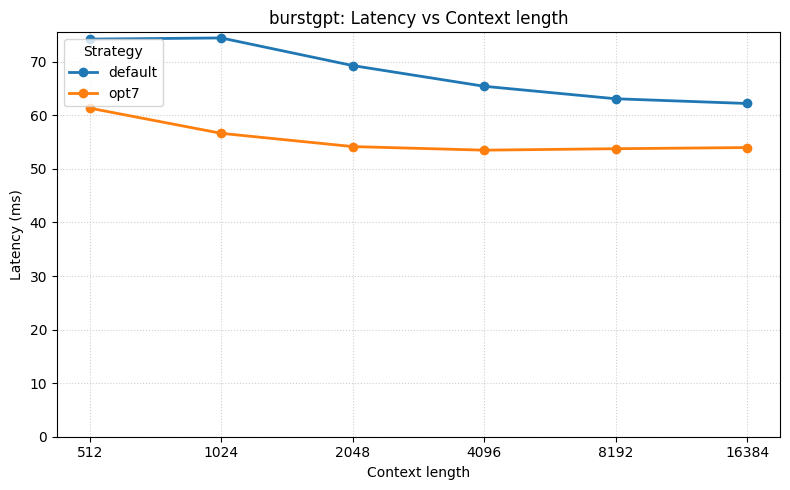

default default
opt7 opt7


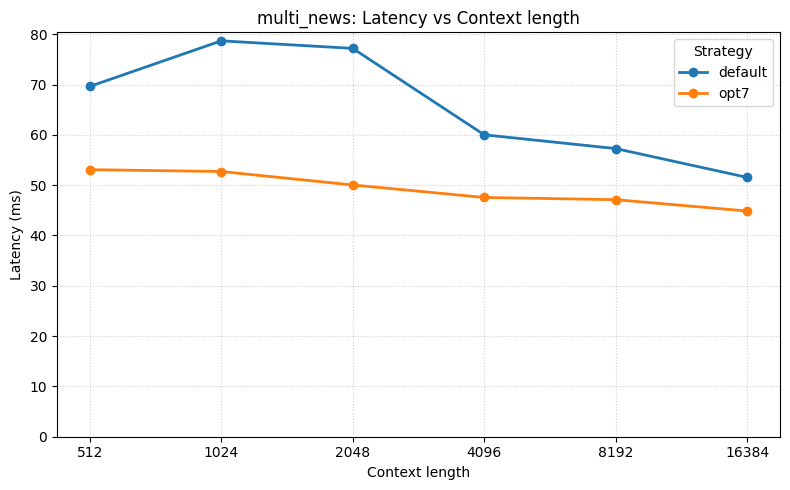

In [60]:
base_dir = "/Users/yejie/Projects/SCS_Lab/IPDPS25_Scheduling/eval_results/ipdps25_sched/venilla_baseline_v0_8_4/"
my_df = defaultdict(lambda: defaultdict())
strategy = "default"
dataset = "burstgpt_offline"
context_lens=(512, 1024, 2048, 4096, 8192, 16384)
dataset_metics_1 = get_avg_latency_df(base_dir, strategy, dataset, context_lens)
my_df["default"]["burstgpt"] = dataset_metics_1

strategy = "evict-optimal-7"
dataset = "burstgpt_offline"
context_lens=(512, 1024, 2048, 4096, 8192, 16384)
dataset_metics_2 = get_avg_latency_df(base_dir, strategy, dataset, context_lens)
my_df["opt7"]["burstgpt"] = dataset_metics_2

plot_latency_vs_context_length("burstgpt", context_lens, my_df)


my_df = defaultdict(lambda: defaultdict())
strategy = "default"
dataset = "longbench--multi_news_offline"
context_lens=(512, 1024, 2048, 4096, 8192, 16384)
dataset_metics_1 = get_avg_latency_df(base_dir, strategy, dataset, context_lens)
my_df["default"]["multi_news"] = dataset_metics_1

strategy = "evict-optimal-7"
dataset = "longbench--multi_news_offline"
context_lens=(512, 1024, 2048, 4096, 8192, 16384)
dataset_metics_2 = get_avg_latency_df(base_dir, strategy, dataset, context_lens)
my_df["opt7"]["multi_news"] = dataset_metics_2

plot_latency_vs_context_length("multi_news", context_lens, my_df)



In [61]:
def plot_throughput_and_itl_vs_context_length(dataset_name, context_lens, my_df_throughput, my_df_latency):
    import matplotlib.pyplot as plt
    import pandas as pd

    strategies = [
        ("default", "default"),
        ("opt7", "opt7"),
        # ("kv-aware", "kv-aware"),
        # ("kv-aware-1", "kv-aware-1"),
    ]

    # Categorical x-axis
    x_vals = list(context_lens)
    x_labels = [str(x) for x in x_vals]
    x_pos = {v: i for i, v in enumerate(x_vals)}

    # Bar positioning per strategy
    num_strategies = len(strategies)
    bar_group_width = 0.8
    bar_width = bar_group_width / max(1, num_strategies)
    offsets = [(-bar_group_width / 2) + (i + 0.5) * bar_width for i in range(num_strategies)]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax2 = ax.twinx()

    colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]
    bar_handles = []
    line_handles = []

    for i, (key, label) in enumerate(strategies):
        color = colors[i % len(colors)]

        # Throughput as bars (left y)
        df_t = None
        if key in my_df_throughput and dataset_name in my_df_throughput[key]:
            df_t = my_df_throughput[key][dataset_name]
        if isinstance(df_t, pd.DataFrame) and not df_t.empty:
            df_t = df_t.sort_values("context_len")
            t_map = df_t.set_index("context_len")["throughput_tok_per_s"]
            heights = [t_map.get(v, float("nan")) for v in x_vals]
            x_bar = [x_pos[v] + offsets[i] for v in x_vals]
            h = ax.bar(x_bar, heights, width=bar_width, color=color, alpha=0.7, label=f"{label} throughput")
            bar_handles.append(h)

        # ITL as lines (right y)
        df_l = None
        if key in my_df_latency and dataset_name in my_df_latency[key]:
            df_l = my_df_latency[key][dataset_name]
        if isinstance(df_l, pd.DataFrame) and not df_l.empty:
            df_l = df_l.sort_values("context_len")
            l_map = df_l.set_index("context_len")["tpot_latency_ms"]
            y_line = [l_map.get(v, float("nan")) for v in x_vals]
            (line,) = ax2.plot(
                range(len(x_vals)),
                y_line,
                marker="o",
                linewidth=2,
                color=color,
                label=f"{label} ITL",
            )
            line_handles.append(line)

    # Labels, ticks, grid
    ax.set_xlabel("Context length")
    ax.set_ylabel("Throughput (tokens/s)")
    ax.set_ylim(bottom=0)
    ax2.set_ylabel("Latency (ms)")
    # ax2.set_ylabel("TTFT Latency (s)")
    ax2.set_ylim(bottom=0)
    ax.set_title(f"{dataset_name}: Throughput (bars) & ITL (lines) vs Context length")

    ax.grid(True, linestyle=":", alpha=0.6)
    ax.set_xticks(range(len(x_vals)))
    ax.set_xticklabels(x_labels)

    # Combined legend
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    if h1 or h2:
        ax.legend(h1 + h2, l1 + l2, ncol=2, title="Strategy", loc="lower right")

    fig.tight_layout()
    plt.show()


def plot_recmp_vs_context_length(dataset_name, context_lens, my_df_recmp):
    import matplotlib.pyplot as plt
    import pandas as pd

    strategies = [
        ("default", "default"),
        ("opt7", "opt7"),
        # ("kv-aware", "kv-aware"),
        # ("kv-aware-1", "kv-aware-1"),
    ]

    # Categorical x-axis
    x_vals = list(context_lens)
    x_labels = [str(x) for x in x_vals]
    x_pos = {v: i for i, v in enumerate(x_vals)}

    # Bar positioning per strategy
    num_strategies = len(strategies)
    bar_group_width = 0.8
    bar_width = bar_group_width / max(1, num_strategies)
    offsets = [(-bar_group_width / 2) + (i + 0.5) * bar_width for i in range(num_strategies)]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax2 = ax.twinx()

    colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]
    bar_handles = []
    line_handles = []

    for i, (key, label) in enumerate(strategies):
        color = colors[i % len(colors)]

        # Throughput as bars (left y)
        df_t = None
        if key in my_df_recmp and dataset_name in my_df_recmp[key]:
            df_t = my_df_recmp[key][dataset_name]
        if isinstance(df_t, pd.DataFrame) and not df_t.empty:
            df_t = df_t.sort_values("context_len")
            t_map = df_t.set_index("context_len")["avg_recmp_tokens"]
            if key == "opt7":
                print(f"opt7 recomputed tokens for {dataset_name}: {t_map}")
            heights = [t_map.get(v, float("nan")) for v in x_vals]
            x_bar = [x_pos[v] + offsets[i] for v in x_vals]
            h = ax.bar(x_bar, heights, width=bar_width, color=color, alpha=0.7, label=f"{label}-recmp-tokens")
            bar_handles.append(h)

            l_map = df_t.set_index("context_len")["avg_recmp_reqs"]
            if key == "opt7":
                print(f"opt7 recomputed tokens for {dataset_name}: {l_map}")
            y_line = [l_map.get(v, float("nan")) for v in x_vals]
            (line,) = ax2.plot(
                range(len(x_vals)),
                y_line,
                marker="o",
                linewidth=2,
                color=color,
                label=f"{label}-recmp-reqs",
            )
            line_handles.append(line)

    # Labels, ticks, grid
    ax.set_xlabel("Context length")
    ax.set_ylabel("Recomputed Tokens")
    ax.set_ylim(bottom=0)
    ax2.set_ylabel("Recomputed Reqs")
    ax2.set_ylim(bottom=0)
    ax.set_title(f"{dataset_name}: Recomputed tokens (bars) & Requests (lines) vs Context length")

    ax.grid(True, linestyle=":", alpha=0.6)
    ax.set_xticks(range(len(x_vals)))
    ax.set_xticklabels(x_labels)

    # Combined legend
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    if h1 or h2:
        ax.legend(h1 + h2, l1 + l2, ncol=2, title="Strategy", loc="lower right")

    fig.tight_layout()
    plt.show()


def plot_thrpt_and_recmp_vs_context_length(dataset_name, context_lens, my_df_throughput, my_df_recmp, right_y_class="recmp-tokens"):
    assert right_y_class in ["recmp-tokens", "recmp-reqs"]
    import matplotlib.pyplot as plt
    import pandas as pd

    strategies = [
        ("default", "default"),
        ("opt7", "opt7"),
    ]

    # Categorical x-axis
    x_vals = list(context_lens)
    x_labels = [str(x) for x in x_vals]
    x_pos = {v: i for i, v in enumerate(x_vals)}

    # Bar positioning per strategy
    num_strategies = len(strategies)
    bar_group_width = 0.8
    bar_width = bar_group_width / max(1, num_strategies)
    offsets = [(-bar_group_width / 2) + (i + 0.5) * bar_width for i in range(num_strategies)]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax2 = ax.twinx()

    colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]
    bar_handles = []
    line_handles = []

    for i, (key, label) in enumerate(strategies):
        color = colors[i % len(colors)]

        # Throughput as bars (left y)
        df_t = None
        if key in my_df_throughput and dataset_name in my_df_throughput[key]:
            df_t = my_df_throughput[key][dataset_name]
        if isinstance(df_t, pd.DataFrame) and not df_t.empty:
            df_t = df_t.sort_values("context_len")
            t_map = df_t.set_index("context_len")["throughput_tok_per_s"]
            heights = [t_map.get(v, float("nan")) for v in x_vals]
            x_bar = [x_pos[v] + offsets[i] for v in x_vals]
            h = ax.bar(x_bar, heights, width=bar_width, color=color, alpha=0.7, label=f"{label} throughput")
            bar_handles.append(h)

        # Recomputed tokens as lines (right y)
        df_right_y = None
        if key in my_df_recmp and dataset_name in my_df_recmp[key]:
            df_right_y = my_df_recmp[key][dataset_name]
        if isinstance(df_right_y, pd.DataFrame) and not df_right_y.empty:
            df_right_y = df_right_y.sort_values("context_len")
            if right_y_class == "recmp-tokens":
                right_y_map = df_right_y.set_index("context_len")["avg_recmp_tokens"]
                label = f"{label}-recmp-tokens"
                y_line = [right_y_map.get(v, float("nan")) / 1e6 for v in x_vals]
            else:
                right_y_map = df_right_y.set_index("context_len")["avg_recmp_reqs"]
                label = f"{label}-recmp-reqs"
                y_line = [right_y_map.get(v, float("nan")) for v in x_vals]
            
            (line,) = ax2.plot(
                range(len(x_vals)),
                y_line,
                marker="o",
                linewidth=2,
                color=color,
                label=f"{label}",
            )
            line_handles.append(line)

    # Labels, ticks, grid
    ax.set_xlabel("Context length")
    ax.set_ylabel("Throughput (tokens/s)")
    ax.set_ylim(bottom=0)
    if right_y_class == "recmp-tokens":
        ax2.set_ylabel("Recomputed Tokens (M)")
    else:
        ax2.set_ylabel("Recomputed Requests")
    ax2.set_ylim(bottom=0)
    ax.set_title(f"{dataset_name}: Throughput (bars) & Recomputations (lines) vs Context length")

    ax.grid(True, linestyle=":", alpha=0.6)
    ax.set_xticks(range(len(x_vals)))
    ax.set_xticklabels(x_labels)

    # Combined legend
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    if h1 or h2:
        ax.legend(h1 + h2, l1 + l2, ncol=2, title="Strategy", loc="lower right")

    fig.tight_layout()
    plt.show()


def plot_TTFT_and_ITL_latency_vs_context_length(dataset_name, context_lens, my_df_latency):
    import matplotlib.pyplot as plt
    import pandas as pd

    strategies = [
        ("default", "default"),
        ("opt7", "opt7"),
    ]

    # Categorical x-axis
    x_vals = list(context_lens)
    x_labels = [str(x) for x in x_vals]
    x_pos = {v: i for i, v in enumerate(x_vals)}

    # Bar positioning per strategy
    num_strategies = len(strategies)
    bar_group_width = 0.8
    bar_width = bar_group_width / max(1, num_strategies)
    offsets = [(-bar_group_width / 2) + (i + 0.5) * bar_width for i in range(num_strategies)]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax2 = ax.twinx()

    colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]
    bar_handles = []
    line_handles = []

    for i, (key, label) in enumerate(strategies):
        color = colors[i % len(colors)]

        # TTFT latency as bars (left y)
        df_l = None
        if key in my_df_latency and dataset_name in my_df_latency[key]:
            df_l = my_df_latency[key][dataset_name]
        if isinstance(df_l, pd.DataFrame) and not df_l.empty:
            df_l = df_l.sort_values("context_len")
            ### TTFT latency
            ttft_map = df_l.set_index("context_len")["ttft_latency_ms"]
            heights = [ttft_map.get(v, float("nan")) / 1000 for v in x_vals] ### convert to seconds
            x_bar = [x_pos[v] + offsets[i] for v in x_vals]
            h = ax.bar(x_bar, heights, width=bar_width, color=color, alpha=0.7, label=f"{label}-TTFT")
            bar_handles.append(h)

            ### ITL latency
            itl_map = df_l.set_index("context_len")["tpot_latency_ms"]
            y_line = [itl_map.get(v, float("nan")) for v in x_vals] ### Keep use ms
            (line,) = ax2.plot(
                range(len(x_vals)),
                y_line,
                marker="o",
                linewidth=2,
                color=color,
                label=f"{label}-ITL",
            )
            line_handles.append(line)

            # itl_map = df_l.set_index("context_len")["tpot_latency_ms_p99"]
            # y_line = [itl_map.get(v, float("nan")) for v in x_vals] ### Keep use ms
            # (line,) = ax2.plot(
            #     range(len(x_vals)),
            #     y_line,
            #     linestyle="--",
            #     marker="^",
            #     linewidth=2,
            #     color=color,
            #     label=f"{label}-ITL",
            # )
            # line_handles.append(line)

            # itl_map = df_l.set_index("context_len")["tpot_latency_ms_p95"]
            # y_line = [itl_map.get(v, float("nan")) for v in x_vals] ### Keep use ms
            # (line,) = ax2.plot(
            #     range(len(x_vals)),
            #     y_line,
            #     linestyle=":",
            #     marker="*",
            #     linewidth=2,
            #     color=color,
            #     label=f"{label}-ITL",
            # )
            # line_handles.append(line)

    # Labels, ticks, grid
    ax.set_xlabel("Context length")
    ax.set_ylabel("TTFT Latency (s)")
    ax.set_ylim(bottom=0)
    ax2.set_ylabel("ITL Latency (ms)")
    ax2.set_ylim(bottom=0)
    ax.set_title(f"{dataset_name}: TTFT (bars) & ITL (lines) vs Context length")

    ax.grid(True, linestyle=":", alpha=0.6)
    ax.set_xticks(range(len(x_vals)))
    ax.set_xticklabels(x_labels)

    # Combined legend
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    if h1 or h2:
        ax.legend(h1 + h2, l1 + l2, ncol=2, title="Strategy", loc="lower right")

    fig.tight_layout()
    plt.show() 


In [62]:
def plot_per_request_itl(data, title=None):
    import matplotlib.pyplot as plt
    import pandas as pd

    col = "tpot_latency_ms" if "tpot_latency_ms" in data.columns else None
    if col is None:
        raise KeyError("'tpot_latency_ms' not found in DataFrame columns")

    x = data["request_id"] if "request_id" in data.columns else data.index
    y = data[col]
    avg_itl = y.mean()

    plt.figure(figsize=(10, 4))
    plt.plot(range(len(y)), y.values, linestyle='-', linewidth=0.8, alpha=0.8)
    plt.axhline(y=avg_itl, color='red', linestyle='--', linewidth=2, label=f'Average ITL: {avg_itl:.2f} ms')
    plt.ylim(bottom=0, top=900)
    plt.xlabel("Request" if "request_id" not in data.columns else "Request ID")
    plt.ylabel("Latency (ms)")
    if title:
        plt.title(title)
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.tight_layout()
    plt.show()


def plot_per_request_ttft(data, title=None):
    import matplotlib.pyplot as plt
    import pandas as pd

    col = "ttft_latency_ms" if "ttft_latency_ms" in data.columns else None
    if col is None:
        raise KeyError("'ttft_latency_ms' not found in DataFrame columns")

    x = data["request_id"] if "request_id" in data.columns else data.index
    y = data[col] / 1000

    plt.figure(figsize=(10, 4))
    plt.plot(range(len(y)), y.values, linestyle='-', linewidth=0.8, alpha=0.8)
    plt.xlabel("Request" if "request_id" not in data.columns else "Request ID")
    plt.ylabel("Latency (s)")
    if title:
        plt.title(title)
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.tight_layout()
    plt.show()

def plot_queued_time(data, title=None):
    import matplotlib.pyplot as plt
    import pandas as pd

    col = "queued_time_ms" if "queued_time_ms" in data.columns else None
    if col is None:
        raise KeyError("'queued_time_ms' not found in DataFrame columns")

    x = data["request_id"] if "request_id" in data.columns else data.index
    y = data[col]

    plt.figure(figsize=(10, 4))
    plt.plot(range(len(y)), y.values/1000, linestyle='-', linewidth=0.8, alpha=0.8)
    plt.xlabel("Request" if "request_id" not in data.columns else "Request ID")
    plt.ylabel("Latency (s)")
    if title:
        plt.title(title)
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.tight_layout()
    plt.show()



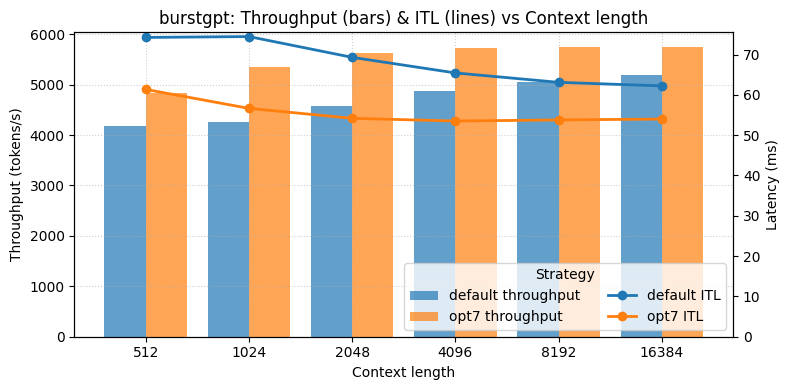

0   60268.73
1   56583.31
2   51659.17
3   48317.74
4   48206.79
5   47938.43
Name: ttft_latency_ms, dtype: float64


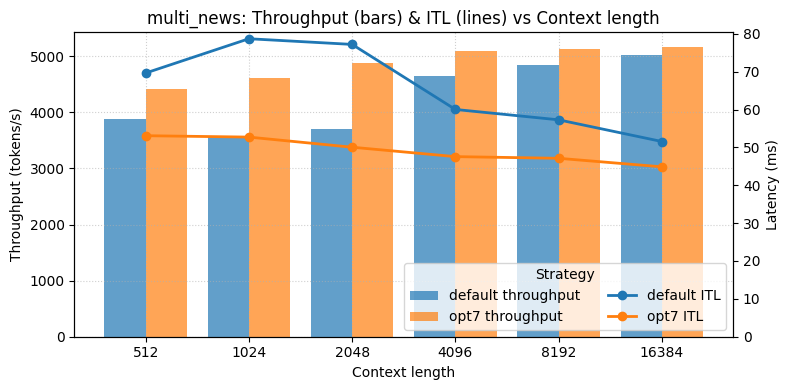

0   218614.02
1   210753.57
2   203927.84
3   196630.53
4   179860.65
5   177087.71
Name: ttft_latency_ms, dtype: float64


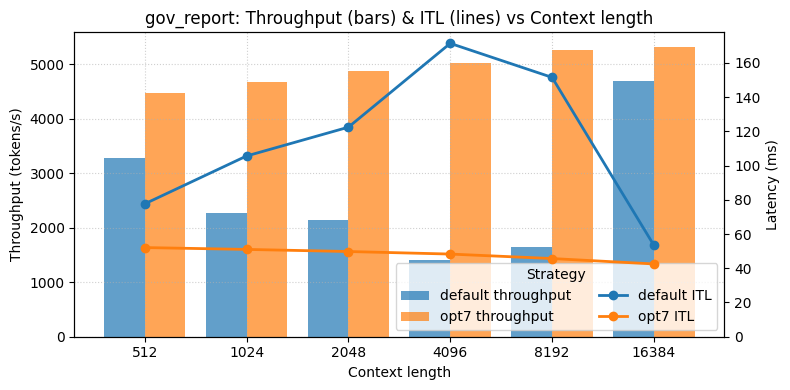

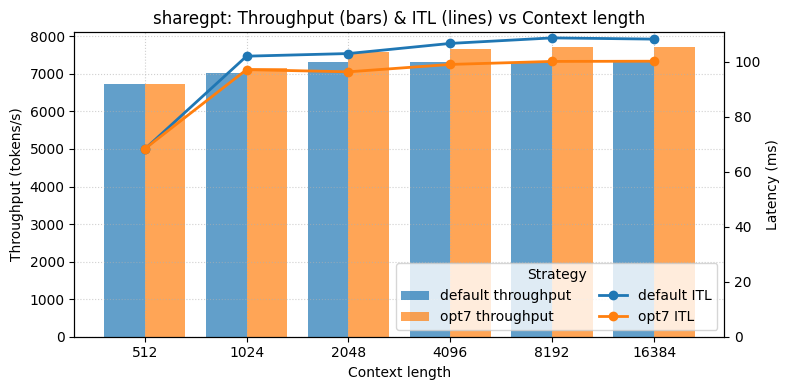

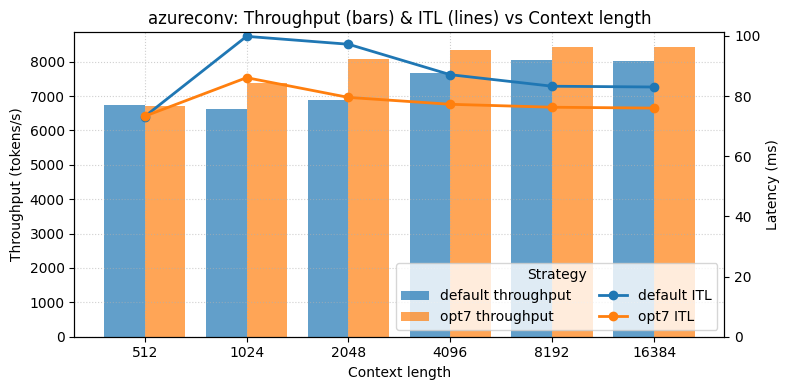

In [63]:
from collections import defaultdict
from pandas import DataFrame

base_dir = "/Users/yejie/Projects/SCS_Lab/IPDPS25_Scheduling/eval_results/ipdps25_sched/venilla_baseline_v0_8_4/"
context_lens = (512, 1024, 2048, 4096, 8192, 16384)
dataset = "burstgpt_offline"

# Build throughput dict (DataFrames)
my_df_tp = defaultdict(lambda: defaultdict(DataFrame))
strategy = "default"
my_df_tp["default"]["burstgpt"] = get_throughput_df(base_dir, strategy, dataset, context_lens)
strategy = "evict-optimal-7"
my_df_tp["opt7"]["burstgpt"] = get_throughput_df(base_dir, strategy, dataset, context_lens)

# Build latency dict (DataFrames)
my_df_lat = defaultdict(lambda: defaultdict(DataFrame))
strategy = "default"
my_df_lat["default"]["burstgpt"] = get_avg_latency_df(base_dir, strategy, dataset, context_lens)
strategy = "evict-optimal-7"
my_df_lat["opt7"]["burstgpt"] = get_avg_latency_df(base_dir, strategy, dataset, context_lens)

# Plot
plot_throughput_and_itl_vs_context_length("burstgpt", context_lens, my_df_tp, my_df_lat)


# Build throughput dict (DataFrames)
dataset = "longbench--multi_news_offline"
my_df_tp = defaultdict(lambda: defaultdict(DataFrame))
strategy = "default"
my_df_tp["default"]["multi_news"] = get_throughput_df(base_dir, strategy, dataset, context_lens)
strategy = "evict-optimal-7"
my_df_tp["opt7"]["multi_news"] = get_throughput_df(base_dir, strategy, dataset, context_lens)

# Build latency dict (DataFrames)
my_df_lat = defaultdict(lambda: defaultdict(DataFrame))
strategy = "default"
my_df_lat["default"]["multi_news"] = get_avg_latency_df(base_dir, strategy, dataset, context_lens)
strategy = "evict-optimal-7"
my_df_lat["opt7"]["multi_news"] = get_avg_latency_df(base_dir, strategy, dataset, context_lens)

print(my_df_lat["opt7"]["multi_news"]["ttft_latency_ms"])
# Plot
plot_throughput_and_itl_vs_context_length("multi_news", context_lens, my_df_tp, my_df_lat)

# Build throughput dict (DataFrames)
dataset = "longbench--gov_report_offline"
my_df_tp = defaultdict(lambda: defaultdict(DataFrame))
strategy = "default"
my_df_tp["default"]["gov_report"] = get_throughput_df(base_dir, strategy, dataset, context_lens)
strategy = "evict-optimal-7"
my_df_tp["opt7"]["gov_report"] = get_throughput_df(base_dir, strategy, dataset, context_lens)

# Build latency dict (DataFrames)
my_df_lat = defaultdict(lambda: defaultdict(DataFrame))
strategy = "default"
my_df_lat["default"]["gov_report"] = get_avg_latency_df(base_dir, strategy, dataset, context_lens)
strategy = "evict-optimal-7"
my_df_lat["opt7"]["gov_report"] = get_avg_latency_df(base_dir, strategy, dataset, context_lens)

print(my_df_lat["opt7"]["gov_report"]["ttft_latency_ms"])
# Plot
plot_throughput_and_itl_vs_context_length("gov_report", context_lens, my_df_tp, my_df_lat)



# Build throughput dict (DataFrames)
dataset = "sharegpt_offline"
my_df_tp = defaultdict(lambda: defaultdict(DataFrame))
strategy = "default"
my_df_tp["default"]["sharegpt"] = get_throughput_df(base_dir, strategy, dataset, context_lens)
strategy = "evict-optimal-7"
my_df_tp["opt7"]["sharegpt"] = get_throughput_df(base_dir, strategy, dataset, context_lens)

# Build latency dict (DataFrames)
my_df_lat = defaultdict(lambda: defaultdict(DataFrame))
strategy = "default"
my_df_lat["default"]["sharegpt"] = get_avg_latency_df(base_dir, strategy, dataset, context_lens)
strategy = "evict-optimal-7"
my_df_lat["opt7"]["sharegpt"] = get_avg_latency_df(base_dir, strategy, dataset, context_lens)

# Plot
plot_throughput_and_itl_vs_context_length("sharegpt", context_lens, my_df_tp, my_df_lat)


# Build throughput dict (DataFrames)
dataset = "azureconv_offline"
my_df_tp = defaultdict(lambda: defaultdict(DataFrame))
strategy = "default"
my_df_tp["default"]["azureconv"] = get_throughput_df(base_dir, strategy, dataset, context_lens)
strategy = "evict-optimal-7"
my_df_tp["opt7"]["azureconv"] = get_throughput_df(base_dir, strategy, dataset, context_lens)

# Build latency dict (DataFrames)
my_df_lat = defaultdict(lambda: defaultdict(DataFrame))
strategy = "default"
my_df_lat["default"]["azureconv"] = get_avg_latency_df(base_dir, strategy, dataset, context_lens)
strategy = "evict-optimal-7"
my_df_lat["opt7"]["azureconv"] = get_avg_latency_df(base_dir, strategy, dataset, context_lens)

# Plot
plot_throughput_and_itl_vs_context_length("azureconv", context_lens, my_df_tp, my_df_lat)


opt7 recomputed tokens for burstgpt: context_len
512     13487.00
1024    13727.00
2048    21128.00
4096     8395.00
8192     9510.00
16384   16150.00
Name: avg_recmp_tokens, dtype: float64
opt7 recomputed tokens for burstgpt: context_len
512     19.00
1024    10.00
2048    13.00
4096    14.00
8192    21.00
16384   21.00
Name: avg_recmp_reqs, dtype: float64


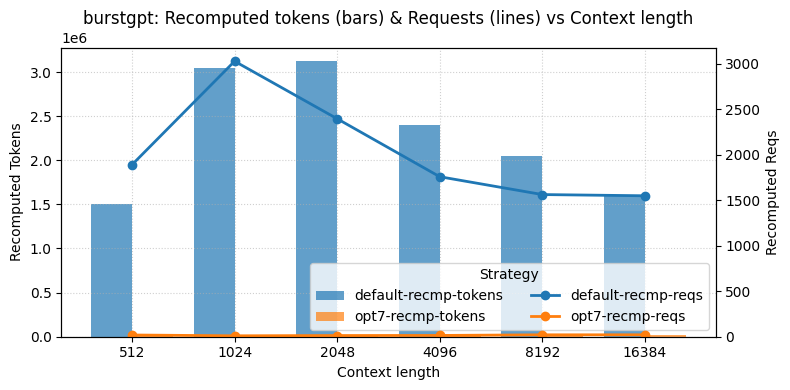

opt7 recomputed tokens for multi_news: context_len
512     58381.00
1024    91561.00
2048    64535.00
4096    26771.00
8192    26805.00
16384   27624.00
Name: avg_recmp_tokens, dtype: float64
opt7 recomputed tokens for multi_news: context_len
512     33.00
1024    34.00
2048    18.00
4096    10.00
8192    10.00
16384   10.00
Name: avg_recmp_reqs, dtype: float64


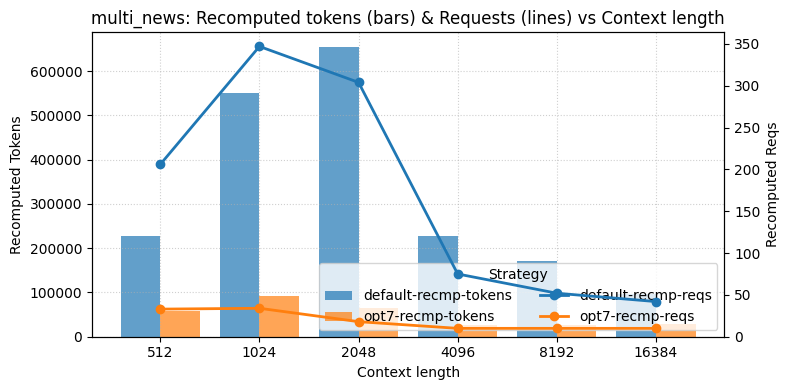

opt7 recomputed tokens for gov_report: context_len
512      88611.00
1024    182482.00
2048    249118.00
4096    230108.00
8192     12274.00
16384    11961.00
Name: avg_recmp_tokens, dtype: float64
opt7 recomputed tokens for gov_report: context_len
512     37.00
1024    47.00
2048    39.00
4096    20.00
8192     1.00
16384    1.00
Name: avg_recmp_reqs, dtype: float64


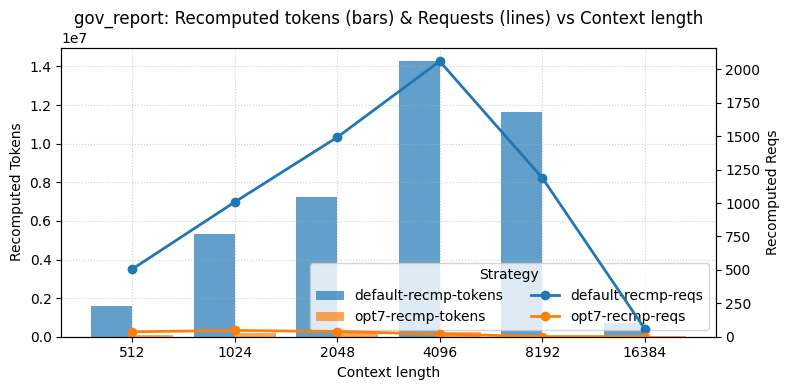

opt7 recomputed tokens for sharegpt: context_len
512        0.00
1024       0.00
2048    4556.00
4096    4094.67
8192    6475.00
16384   6530.00
Name: avg_recmp_tokens, dtype: float64
opt7 recomputed tokens for sharegpt: context_len
512      0.00
1024     0.00
2048    13.00
4096    17.67
8192    32.00
16384   35.00
Name: avg_recmp_reqs, dtype: float64


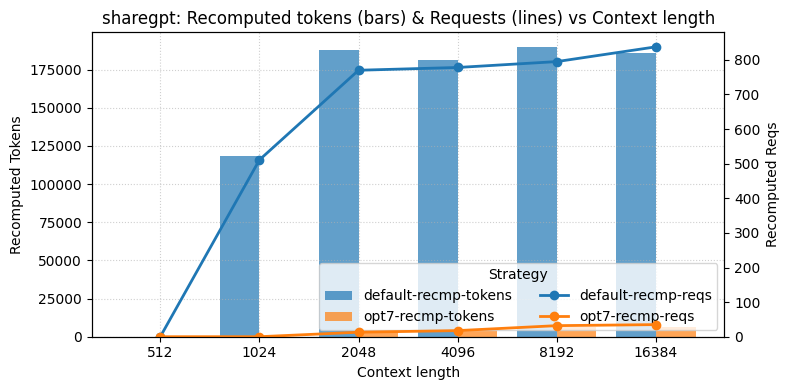

opt7 recomputed tokens for azureconv: context_len
512        0.00
1024       0.00
2048       0.00
4096       0.00
8192    5153.00
16384   5151.00
Name: avg_recmp_tokens, dtype: float64
opt7 recomputed tokens for azureconv: context_len
512     0.00
1024    0.00
2048    0.00
4096    0.00
8192    3.00
16384   3.00
Name: avg_recmp_reqs, dtype: float64


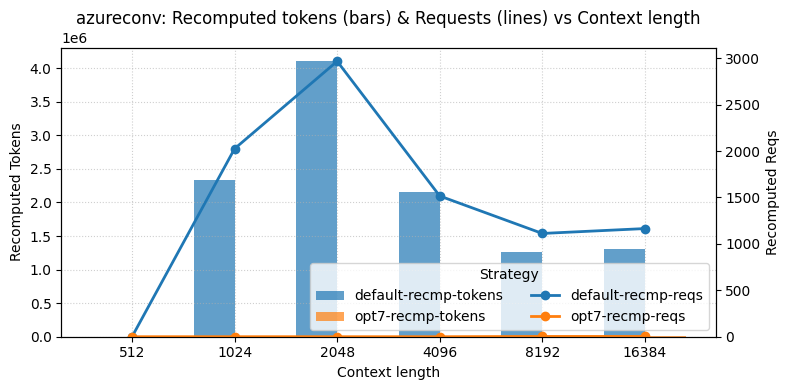

In [64]:
#### Get the number of recomputation requests and tokens vs. context length for different strategies

from collections import defaultdict
from pandas import DataFrame

base_dir = "/Users/yejie/Projects/SCS_Lab/IPDPS25_Scheduling/eval_results/ipdps25_sched/venilla_baseline_v0_8_4/"
context_lens = (512, 1024, 2048, 4096, 8192, 16384)
dataset = "burstgpt_offline"

# Build throughput dict (DataFrames)
my_df_recmp = defaultdict(lambda: defaultdict(DataFrame))
strategy = "default"
my_df_recmp["default"]["burstgpt"] = get_avg_recomputations_df(base_dir, strategy, dataset, context_lens)
strategy = "evict-optimal-7"
my_df_recmp["opt7"]["burstgpt"] = get_avg_recomputations_df(base_dir, strategy, dataset, context_lens)

# Plot
plot_recmp_vs_context_length("burstgpt", context_lens, my_df_recmp)


# Build throughput dict (DataFrames)
dataset = "longbench--multi_news_offline"
my_df_recmp = defaultdict(lambda: defaultdict(DataFrame))
strategy = "default"
my_df_recmp["default"]["multi_news"] = get_avg_recomputations_df(base_dir, strategy, dataset, context_lens)
strategy = "evict-optimal-7"
my_df_recmp["opt7"]["multi_news"] = get_avg_recomputations_df(base_dir, strategy, dataset, context_lens)

plot_recmp_vs_context_length("multi_news", context_lens, my_df_recmp)

# Build throughput dict (DataFrames)
dataset = "longbench--gov_report_offline"
my_df_recmp = defaultdict(lambda: defaultdict(DataFrame))
strategy = "default"
my_df_recmp["default"]["gov_report"] = get_avg_recomputations_df(base_dir, strategy, dataset, context_lens)
strategy = "evict-optimal-7"
my_df_recmp["opt7"]["gov_report"] = get_avg_recomputations_df(base_dir, strategy, dataset, context_lens)

# Plot
plot_recmp_vs_context_length("gov_report", context_lens, my_df_recmp)


# Build throughput dict (DataFrames)
dataset = "sharegpt_offline"
my_df_recmp = defaultdict(lambda: defaultdict(DataFrame))
strategy = "default"
my_df_recmp["default"]["sharegpt"] = get_avg_recomputations_df(base_dir, strategy, dataset, context_lens)
strategy = "evict-optimal-7"
my_df_recmp["opt7"]["sharegpt"] = get_avg_recomputations_df(base_dir, strategy, dataset, context_lens)

# Plot
plot_recmp_vs_context_length("sharegpt", context_lens, my_df_recmp)


# Build throughput dict (DataFrames)
dataset = "azureconv_offline"
my_df_recmp = defaultdict(lambda: defaultdict(DataFrame))
strategy = "default"
my_df_recmp["default"]["azureconv"] = get_avg_recomputations_df(base_dir, strategy, dataset, context_lens)
strategy = "evict-optimal-7"
my_df_recmp["opt7"]["azureconv"] = get_avg_recomputations_df(base_dir, strategy, dataset, context_lens)

# Plot
plot_recmp_vs_context_length("azureconv", context_lens, my_df_recmp)


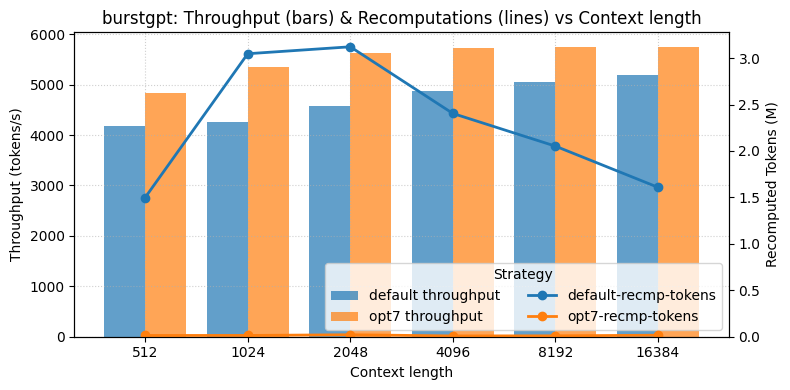

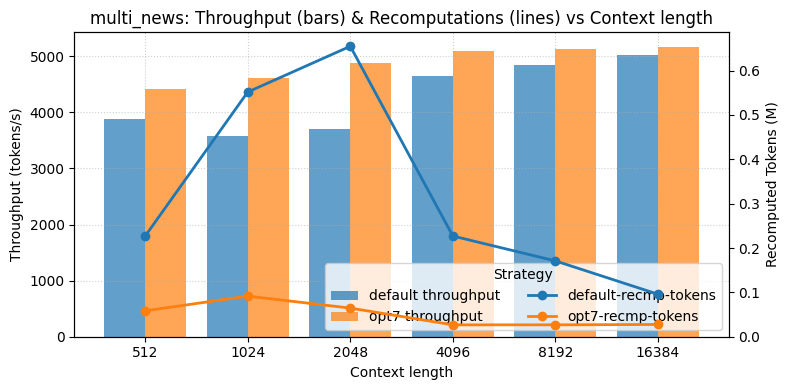

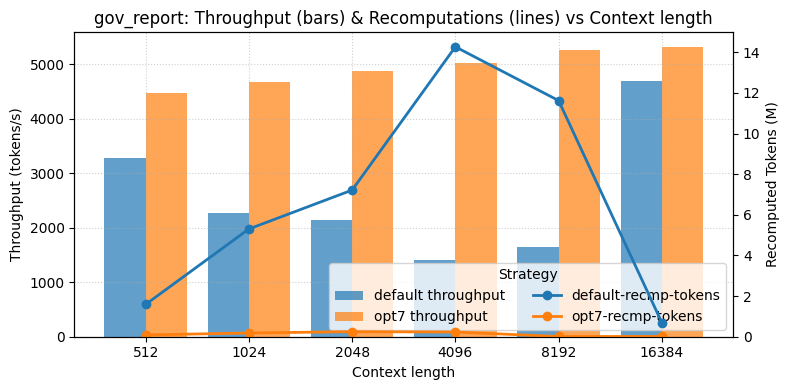

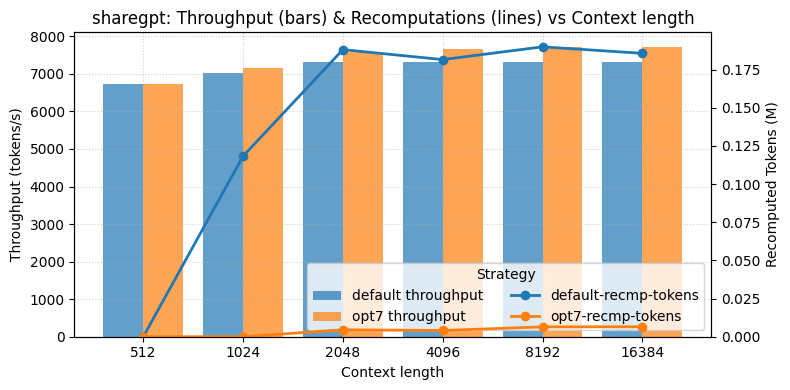

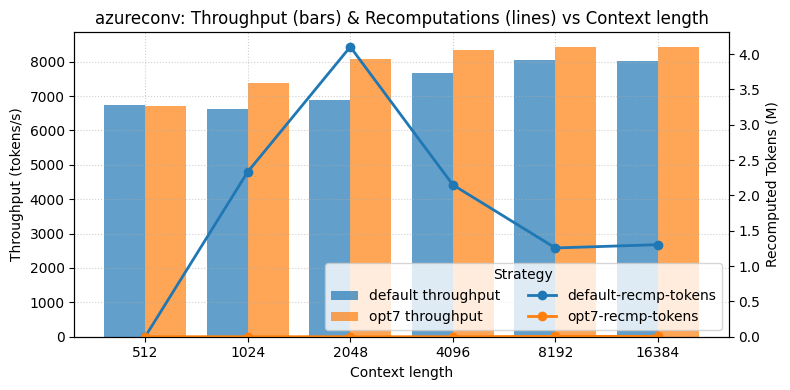

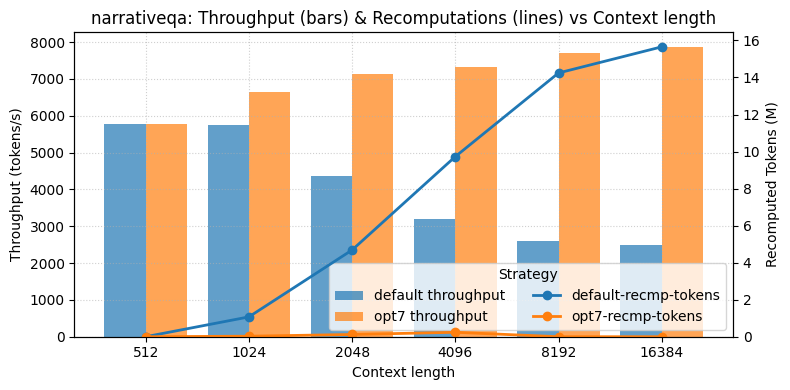

In [65]:
#### Get throughput and recomputation information for different strategies, datasets, and context lengths

from collections import defaultdict
from pandas import DataFrame

base_dir = "/Users/yejie/Projects/SCS_Lab/IPDPS25_Scheduling/eval_results/ipdps25_sched/venilla_baseline_v0_8_4/"
context_lens = (512, 1024, 2048, 4096, 8192, 16384)
dataset = "burstgpt_offline"

# Build throughput dict (DataFrames)
my_df_tp = defaultdict(lambda: defaultdict(DataFrame))
strategy = "default"
my_df_tp["default"]["burstgpt"] = get_throughput_df(base_dir, strategy, dataset, context_lens)
strategy = "evict-optimal-7"
my_df_tp["opt7"]["burstgpt"] = get_throughput_df(base_dir, strategy, dataset, context_lens)

# Build recomputation dict (DataFrames)
my_df_recmp = defaultdict(lambda: defaultdict(DataFrame))
strategy = "default"
my_df_recmp["default"]["burstgpt"] = get_avg_recomputations_df(base_dir, strategy, dataset, context_lens)
strategy = "evict-optimal-7"
my_df_recmp["opt7"]["burstgpt"] = get_avg_recomputations_df(base_dir, strategy, dataset, context_lens)

# Plot
plot_thrpt_and_recmp_vs_context_length("burstgpt", context_lens, my_df_tp, my_df_recmp)


# Build throughput dict (DataFrames)
dataset = "longbench--multi_news_offline"
my_df_tp = defaultdict(lambda: defaultdict(DataFrame))
strategy = "default"
my_df_tp["default"]["multi_news"] = get_throughput_df(base_dir, strategy, dataset, context_lens)
strategy = "evict-optimal-7"
my_df_tp["opt7"]["multi_news"] = get_throughput_df(base_dir, strategy, dataset, context_lens)

# Build recomputation dict (DataFrames)
my_df_recmp = defaultdict(lambda: defaultdict(DataFrame))
strategy = "default"
my_df_recmp["default"]["multi_news"] = get_avg_recomputations_df(base_dir, strategy, dataset, context_lens)
strategy = "evict-optimal-7"
my_df_recmp["opt7"]["multi_news"] = get_avg_recomputations_df(base_dir, strategy, dataset, context_lens)

# Plot
plot_thrpt_and_recmp_vs_context_length("multi_news", context_lens, my_df_tp, my_df_recmp)

# Build throughput dict (DataFrames)
dataset = "longbench--gov_report_offline"
my_df_tp = defaultdict(lambda: defaultdict(DataFrame))
strategy = "default"
my_df_tp["default"]["gov_report"] = get_throughput_df(base_dir, strategy, dataset, context_lens)
strategy = "evict-optimal-7"
my_df_tp["opt7"]["gov_report"] = get_throughput_df(base_dir, strategy, dataset, context_lens)

# Build recomputation dict (DataFrames)
my_df_recmp = defaultdict(lambda: defaultdict(DataFrame))
strategy = "default"
my_df_recmp["default"]["gov_report"] = get_avg_recomputations_df(base_dir, strategy, dataset, context_lens)
strategy = "evict-optimal-7"
my_df_recmp["opt7"]["gov_report"] = get_avg_recomputations_df(base_dir, strategy, dataset, context_lens)

# Plot
plot_thrpt_and_recmp_vs_context_length("gov_report", context_lens, my_df_tp, my_df_recmp)



# Build throughput dict (DataFrames)
dataset = "sharegpt_offline"
my_df_tp = defaultdict(lambda: defaultdict(DataFrame))
strategy = "default"
my_df_tp["default"]["sharegpt"] = get_throughput_df(base_dir, strategy, dataset, context_lens)
strategy = "evict-optimal-7"
my_df_tp["opt7"]["sharegpt"] = get_throughput_df(base_dir, strategy, dataset, context_lens)

# Build recomputation dict (DataFrames)
my_df_recmp = defaultdict(lambda: defaultdict(DataFrame))
strategy = "default"
my_df_recmp["default"]["sharegpt"] = get_avg_recomputations_df(base_dir, strategy, dataset, context_lens)
strategy = "evict-optimal-7"
my_df_recmp["opt7"]["sharegpt"] = get_avg_recomputations_df(base_dir, strategy, dataset, context_lens)

# Plot
plot_thrpt_and_recmp_vs_context_length("sharegpt", context_lens, my_df_tp, my_df_recmp)


# Build throughput dict (DataFrames)
dataset = "azureconv_offline"
my_df_tp = defaultdict(lambda: defaultdict(DataFrame))
strategy = "default"
my_df_tp["default"]["azureconv"] = get_throughput_df(base_dir, strategy, dataset, context_lens)
strategy = "evict-optimal-7"
my_df_tp["opt7"]["azureconv"] = get_throughput_df(base_dir, strategy, dataset, context_lens)

# Build recomputation dict (DataFrames)
my_df_recmp = defaultdict(lambda: defaultdict(DataFrame))
strategy = "default"
my_df_recmp["default"]["azureconv"] = get_avg_recomputations_df(base_dir, strategy, dataset, context_lens)
strategy = "evict-optimal-7"
my_df_recmp["opt7"]["azureconv"] = get_avg_recomputations_df(base_dir, strategy, dataset, context_lens)

# Plot
plot_thrpt_and_recmp_vs_context_length("azureconv", context_lens, my_df_tp, my_df_recmp)


# Build throughput dict (DataFrames)
dataset = "longbench--narrativeqa_offline"
my_df_tp = defaultdict(lambda: defaultdict(DataFrame))
strategy = "default"
my_df_tp["default"]["narrativeqa"] = get_throughput_df(base_dir, strategy, dataset, context_lens)
strategy = "evict-optimal-7"
my_df_tp["opt7"]["narrativeqa"] = get_throughput_df(base_dir, strategy, dataset, context_lens)

# Build recomputation dict (DataFrames)
my_df_recmp = defaultdict(lambda: defaultdict(DataFrame))
strategy = "default"
my_df_recmp["default"]["narrativeqa"] = get_avg_recomputations_df(base_dir, strategy, dataset, context_lens)
strategy = "evict-optimal-7"
my_df_recmp["opt7"]["narrativeqa"] = get_avg_recomputations_df(base_dir, strategy, dataset, context_lens)

# Plot
plot_thrpt_and_recmp_vs_context_length("narrativeqa", context_lens, my_df_tp, my_df_recmp)

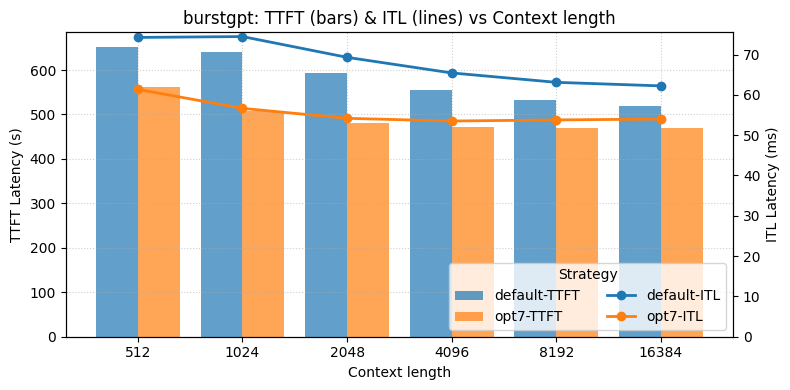

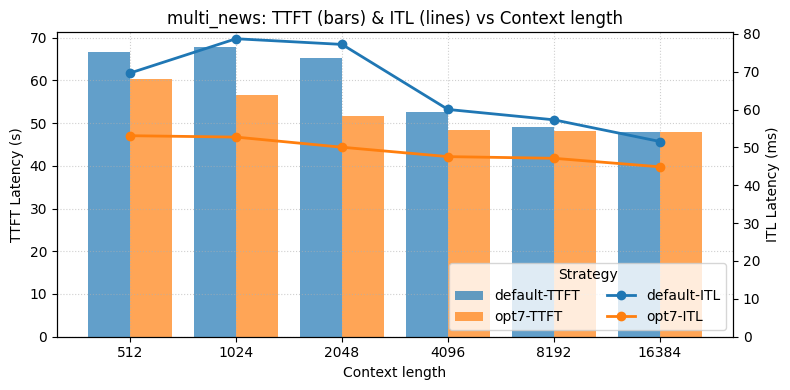

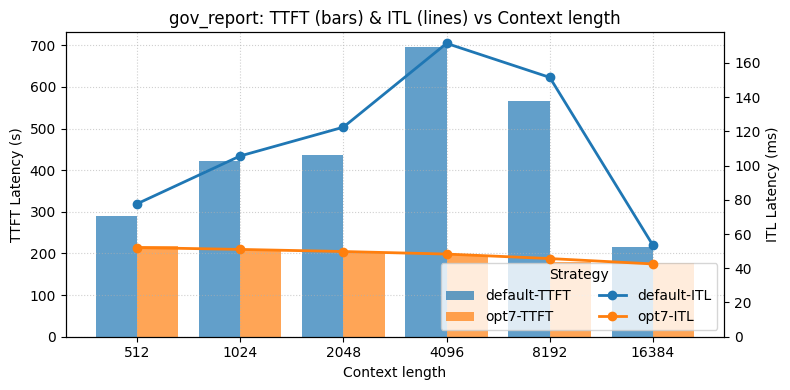

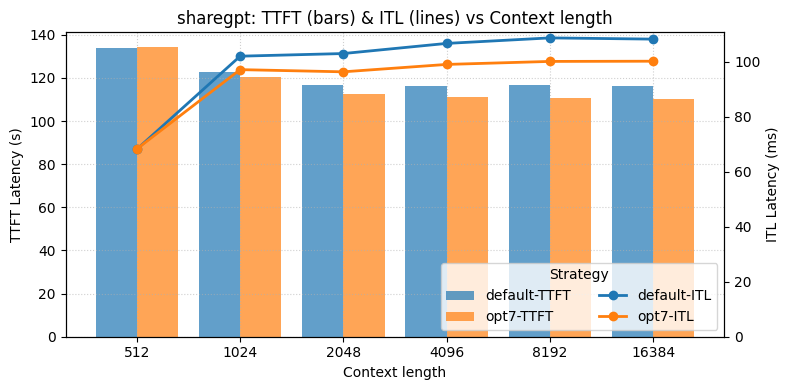

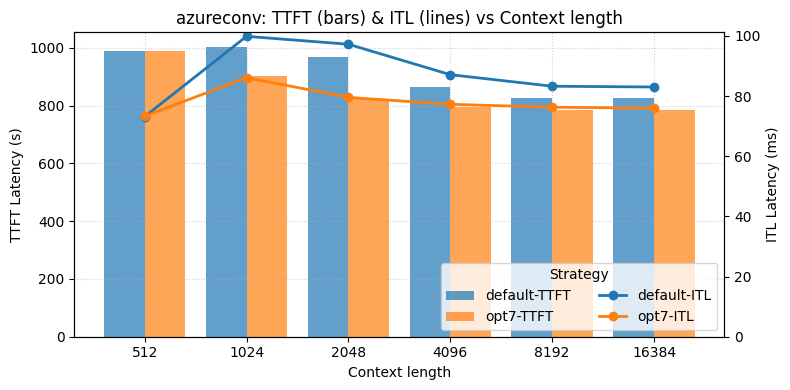

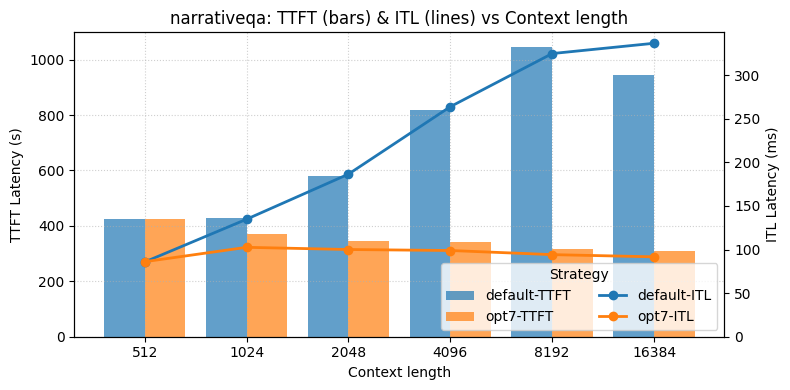

In [66]:
#### Get Latency information for different strategies, datasets, and context lengths

from collections import defaultdict
from pandas import DataFrame

base_dir = "/Users/yejie/Projects/SCS_Lab/IPDPS25_Scheduling/eval_results/ipdps25_sched/venilla_baseline_v0_8_4/"
context_lens = (512, 1024, 2048, 4096, 8192, 16384)

dataset = "burstgpt_offline"
# Build latency dict (DataFrames)
my_df_lat = defaultdict(lambda: defaultdict(DataFrame))
strategy = "default"
my_df_lat["default"]["burstgpt"] = get_avg_latency_df(base_dir, strategy, dataset, context_lens)
strategy = "evict-optimal-7"
my_df_lat["opt7"]["burstgpt"] = get_avg_latency_df(base_dir, strategy, dataset, context_lens)

# Plot
plot_TTFT_and_ITL_latency_vs_context_length("burstgpt", context_lens, my_df_lat)


# Build latency dict (DataFrames)
dataset = "longbench--multi_news_offline"
my_df_lat = defaultdict(lambda: defaultdict(DataFrame))
strategy = "default"
my_df_lat["default"]["multi_news"] = get_avg_latency_df(base_dir, strategy, dataset, context_lens)
strategy = "evict-optimal-7"
my_df_lat["opt7"]["multi_news"] = get_avg_latency_df(base_dir, strategy, dataset, context_lens)

# Plot
plot_TTFT_and_ITL_latency_vs_context_length("multi_news", context_lens, my_df_lat)


# Build latency dict (DataFrames)
dataset = "longbench--gov_report_offline"
my_df_lat = defaultdict(lambda: defaultdict(DataFrame))
strategy = "default"
my_df_lat["default"]["gov_report"] = get_avg_latency_df(base_dir, strategy, dataset, context_lens)
strategy = "evict-optimal-7"
my_df_lat["opt7"]["gov_report"] = get_avg_latency_df(base_dir, strategy, dataset, context_lens)

# Plot
plot_TTFT_and_ITL_latency_vs_context_length("gov_report", context_lens, my_df_lat)


# Build latency dict (DataFrames)
dataset = "sharegpt_offline"
my_df_lat = defaultdict(lambda: defaultdict(DataFrame))
strategy = "default"
my_df_lat["default"]["sharegpt"] = get_avg_latency_df(base_dir, strategy, dataset, context_lens)
strategy = "evict-optimal-7"
my_df_lat["opt7"]["sharegpt"] = get_avg_latency_df(base_dir, strategy, dataset, context_lens)

# Plot
plot_TTFT_and_ITL_latency_vs_context_length("sharegpt", context_lens, my_df_lat)


# Build latency dict (DataFrames)
dataset = "azureconv_offline"
my_df_lat = defaultdict(lambda: defaultdict(DataFrame))
strategy = "default"
my_df_lat["default"]["azureconv"] = get_avg_latency_df(base_dir, strategy, dataset, context_lens)
strategy = "evict-optimal-7"
my_df_lat["opt7"]["azureconv"] = get_avg_latency_df(base_dir, strategy, dataset, context_lens)

# Plot
plot_TTFT_and_ITL_latency_vs_context_length("azureconv", context_lens, my_df_lat)

# Build latency dict (DataFrames)
dataset = "longbench--narrativeqa_offline"
my_df_lat = defaultdict(lambda: defaultdict(DataFrame))
strategy = "default"
my_df_lat["default"]["narrativeqa"] = get_avg_latency_df(base_dir, strategy, dataset, context_lens)
strategy = "evict-optimal-7"
my_df_lat["opt7"]["narrativeqa"] = get_avg_latency_df(base_dir, strategy, dataset, context_lens)

# Plot
plot_TTFT_and_ITL_latency_vs_context_length("narrativeqa", context_lens, my_df_lat)

<>:8: SyntaxWarning: invalid escape sequence '\d'
<>:25: SyntaxWarning: invalid escape sequence '\d'
<>:8: SyntaxWarning: invalid escape sequence '\d'
<>:25: SyntaxWarning: invalid escape sequence '\d'
/var/folders/hr/3964mgc15nl4psz65tsnbtx40000gn/T/ipykernel_3394/3710998550.py:8: SyntaxWarning: invalid escape sequence '\d'
  data_sorted['_numeric_id'] = data_sorted['request_id'].str.extract('(\d+)').astype(int)
/var/folders/hr/3964mgc15nl4psz65tsnbtx40000gn/T/ipykernel_3394/3710998550.py:25: SyntaxWarning: invalid escape sequence '\d'
  data_sorted['_numeric_id'] = data_sorted['request_id'].str.extract('(\d+)').astype(int)


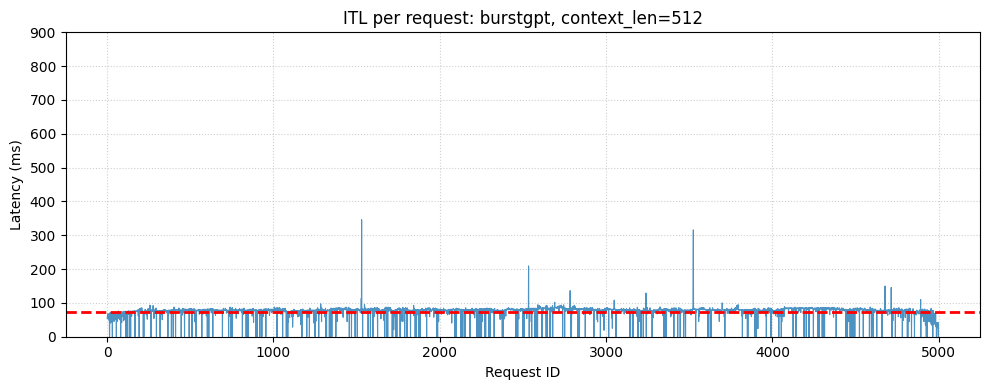

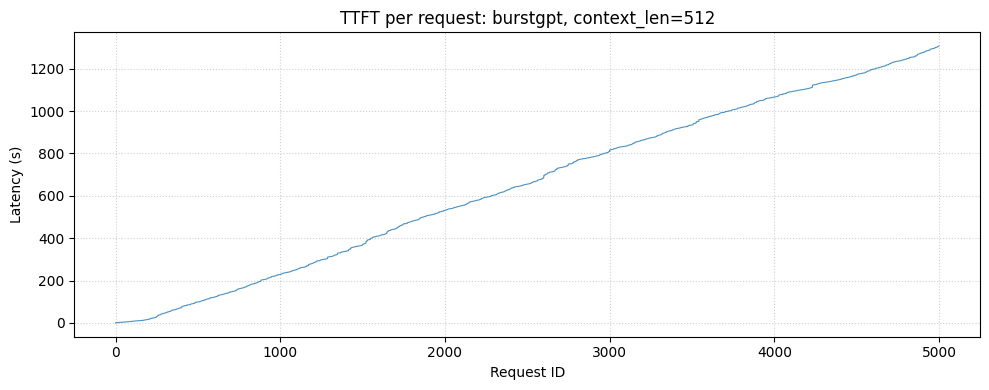

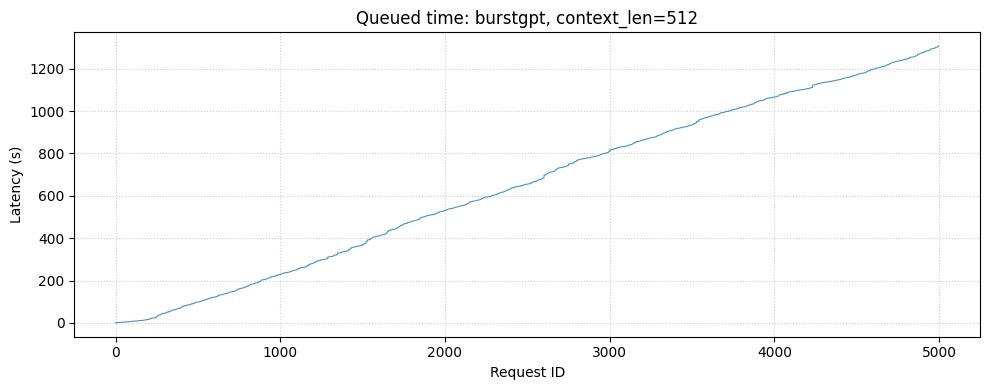

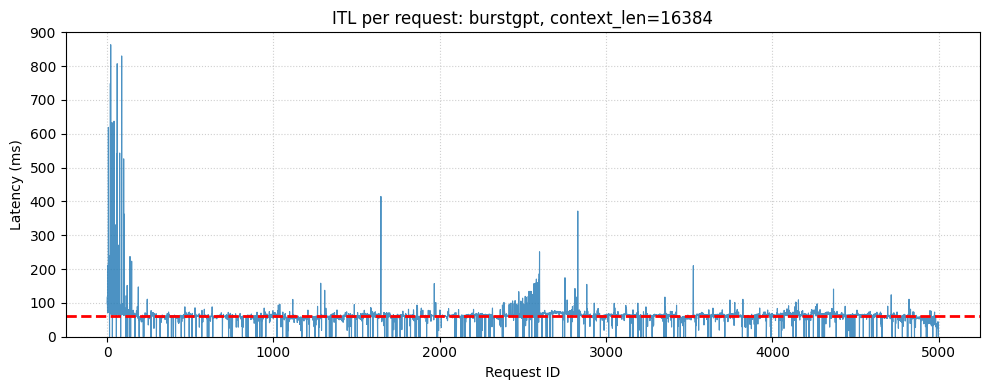

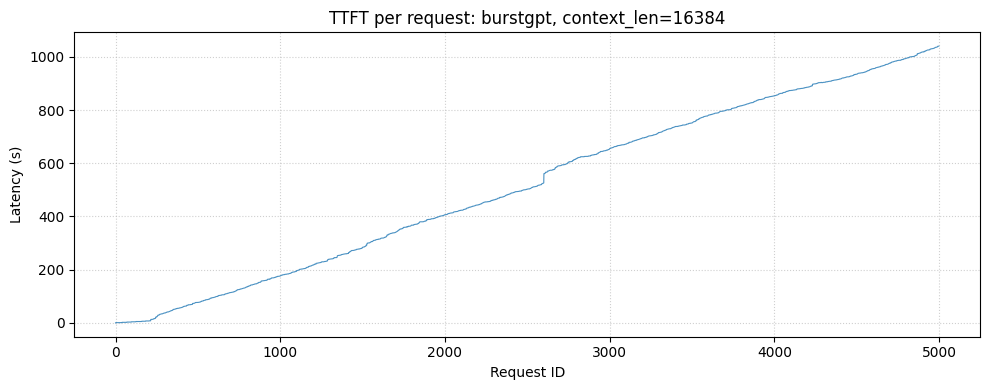

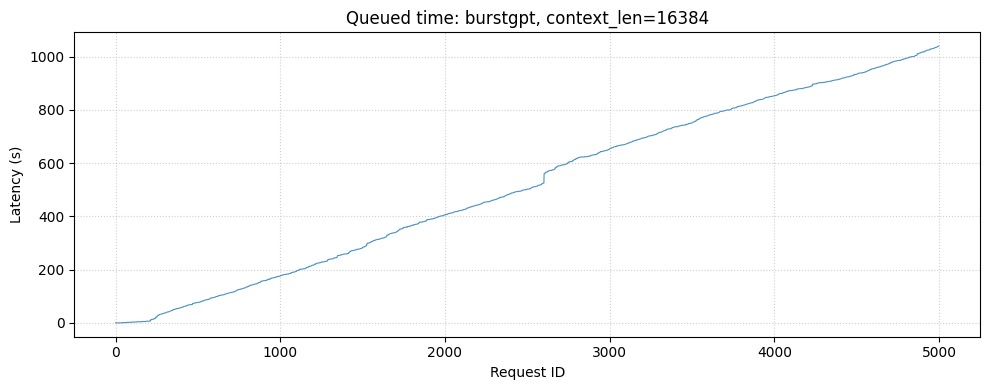

In [67]:
dataset = "/Users/yejie/Projects/SCS_Lab/IPDPS25_Scheduling/eval_results/ipdps25_sched/venilla_baseline_v0_8_4/default/logs_v1_Llama-3.1-8B_ofd0/burstgpt_offline/default_c32768_g-1_r5000_gp0.9_bt512_1_req_stats.csv"

data = pd.read_csv(dataset)
dataset_name = "burstgpt"
# Fix sorting: sort by numeric part of request_id (e.g., "test123" -> 123)
data_sorted = data.copy()
if "request_id" in data.columns:
    data_sorted['_numeric_id'] = data_sorted['request_id'].str.extract('(\d+)').astype(int)
    data_sorted = data_sorted.sort_values('_numeric_id').drop(columns=['_numeric_id'])
else:
    data_sorted = data

plot_per_request_itl(data_sorted, title=f"ITL per request: {dataset_name}, context_len=512")
plot_per_request_ttft(data_sorted, title=f"TTFT per request: {dataset_name}, context_len=512")
plot_queued_time(data_sorted, title=f"Queued time: {dataset_name}, context_len=512")


dataset = "/Users/yejie/Projects/SCS_Lab/IPDPS25_Scheduling/eval_results/ipdps25_sched/venilla_baseline_v0_8_4/default/logs_v1_Llama-3.1-8B_ofd0/burstgpt_offline/default_c32768_g-1_r5000_gp0.9_bt16384_1_req_stats.csv"

data = pd.read_csv(dataset)
dataset_name = "burstgpt"
# Fix sorting: sort by numeric part of request_id (e.g., "test123" -> 123)
data_sorted = data.copy()
if "request_id" in data.columns:
    data_sorted['_numeric_id'] = data_sorted['request_id'].str.extract('(\d+)').astype(int)
    data_sorted = data_sorted.sort_values('_numeric_id').drop(columns=['_numeric_id'])
else:
    data_sorted = data

plot_per_request_itl(data_sorted, title=f"ITL per request: {dataset_name}, context_len=16384")
plot_per_request_ttft(data_sorted, title=f"TTFT per request: {dataset_name}, context_len=16384")
plot_queued_time(data_sorted, title=f"Queued time: {dataset_name}, context_len=16384")

<>:8: SyntaxWarning: invalid escape sequence '\d'
<>:25: SyntaxWarning: invalid escape sequence '\d'
<>:8: SyntaxWarning: invalid escape sequence '\d'
<>:25: SyntaxWarning: invalid escape sequence '\d'
/var/folders/hr/3964mgc15nl4psz65tsnbtx40000gn/T/ipykernel_3394/247407828.py:8: SyntaxWarning: invalid escape sequence '\d'
  data_sorted['_numeric_id'] = data_sorted['request_id'].str.extract('(\d+)').astype(int)
/var/folders/hr/3964mgc15nl4psz65tsnbtx40000gn/T/ipykernel_3394/247407828.py:25: SyntaxWarning: invalid escape sequence '\d'
  data_sorted['_numeric_id'] = data_sorted['request_id'].str.extract('(\d+)').astype(int)


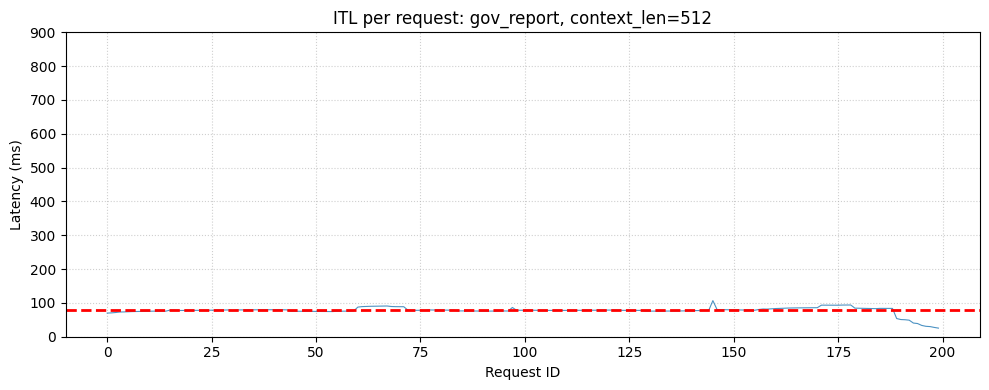

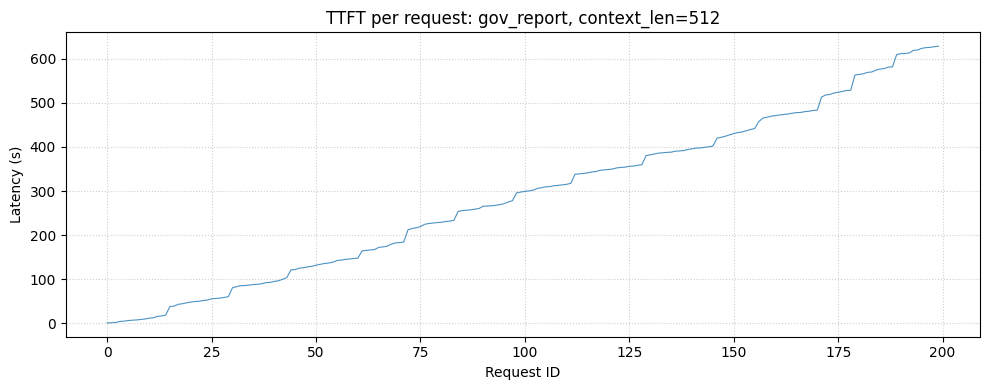

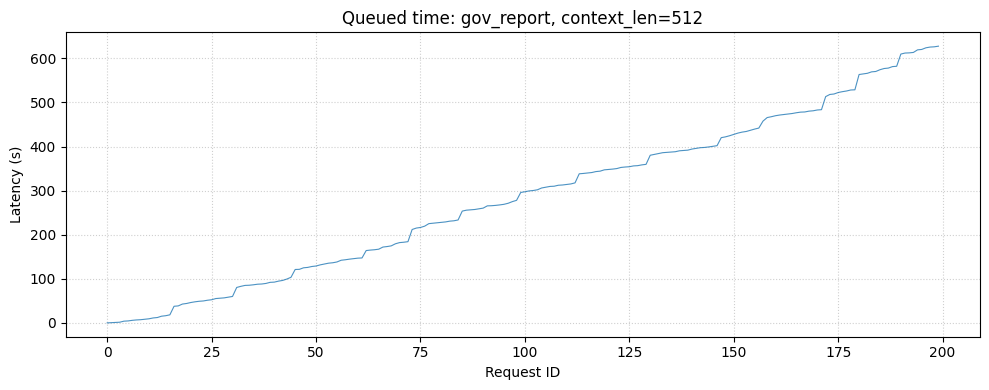

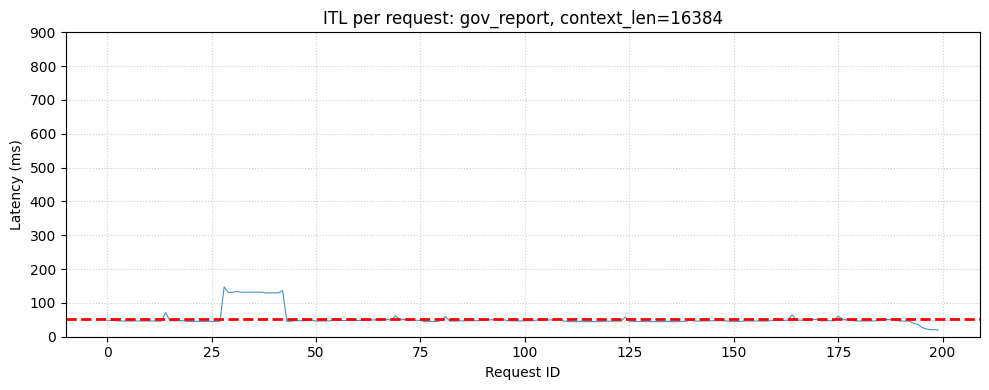

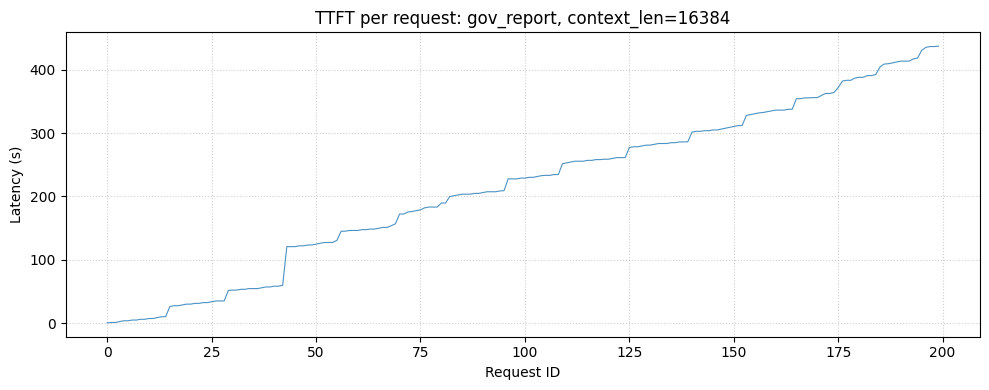

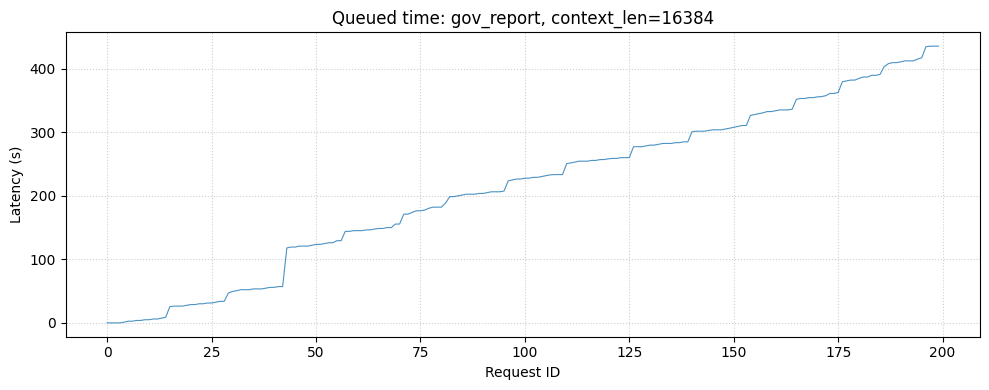

In [68]:
dataset = "/Users/yejie/Projects/SCS_Lab/IPDPS25_Scheduling/eval_results/ipdps25_sched/venilla_baseline_v0_8_4/default/logs_v1_Llama-3.1-8B_ofd0/longbench--gov_report_offline/default_c32768_g512_r200_gp0.9_bt512_1_req_stats.csv"

data = pd.read_csv(dataset)
dataset_name = "gov_report"
# Fix sorting: sort by numeric part of request_id (e.g., "test123" -> 123)
data_sorted = data.copy()
if "request_id" in data.columns:
    data_sorted['_numeric_id'] = data_sorted['request_id'].str.extract('(\d+)').astype(int)
    data_sorted = data_sorted.sort_values('_numeric_id').drop(columns=['_numeric_id'])
else:
    data_sorted = data

plot_per_request_itl(data_sorted, title=f"ITL per request: {dataset_name}, context_len=512")
plot_per_request_ttft(data_sorted, title=f"TTFT per request: {dataset_name}, context_len=512")
plot_queued_time(data_sorted, title=f"Queued time: {dataset_name}, context_len=512")


dataset = "/Users/yejie/Projects/SCS_Lab/IPDPS25_Scheduling/eval_results/ipdps25_sched/venilla_baseline_v0_8_4/default/logs_v1_Llama-3.1-8B_ofd0/longbench--gov_report_offline/default_c32768_g512_r200_gp0.9_bt16384_1_req_stats.csv"

data = pd.read_csv(dataset)
dataset_name = "gov_report"
# Fix sorting: sort by numeric part of request_id (e.g., "test123" -> 123)
data_sorted = data.copy()
if "request_id" in data.columns:
    data_sorted['_numeric_id'] = data_sorted['request_id'].str.extract('(\d+)').astype(int)
    data_sorted = data_sorted.sort_values('_numeric_id').drop(columns=['_numeric_id'])
else:
    data_sorted = data

plot_per_request_itl(data_sorted, title=f"ITL per request: {dataset_name}, context_len=16384")
plot_per_request_ttft(data_sorted, title=f"TTFT per request: {dataset_name}, context_len=16384")
plot_queued_time(data_sorted, title=f"Queued time: {dataset_name}, context_len=16384")

In [69]:
def calculate_tail_latency_stats(data, latency_col='tpot_latency_ms', percentiles=[50, 90, 95, 99, 99.9]):
    """
    Calculate tail latency statistics for a given dataset.
    
    Args:
        data: DataFrame containing latency data
        latency_col: Column name for latency values
        percentiles: List of percentiles to calculate
        
    Returns:
        Dictionary with latency statistics
    """
    import numpy as np
    
    if latency_col not in data.columns:
        raise KeyError(f"'{latency_col}' not found in DataFrame columns")
    
    latencies = data[latency_col].dropna()
    
    stats = {
        'count': len(latencies),
        'mean': latencies.mean(),
        'std': latencies.std(),
        'min': latencies.min(),
        'max': latencies.max()
    }
    
    # Calculate percentiles
    for p in percentiles:
        stats[f'p{p}'] = np.percentile(latencies, p)
    
    return stats

def compare_tail_latencies(data_dict, latency_col='tpot_latency_ms', percentiles=[50, 90, 95, 99, 99.9]):
    """
    Compare tail latencies across multiple datasets.
    
    Args:
        data_dict: Dictionary with {name: DataFrame} pairs
        latency_col: Column name for latency values
        percentiles: List of percentiles to calculate
        
    Returns:
        DataFrame with comparison results
    """
    import pandas as pd
    
    results = {}
    for name, data in data_dict.items():
        stats = calculate_tail_latency_stats(data, latency_col, percentiles)
        results[name] = stats
    
    # Convert to DataFrame for easy comparison
    comparison_df = pd.DataFrame(results).T
    return comparison_df

def plot_tail_latency_comparison(data_dict, latency_col='tpot_latency_ms', percentiles=[90, 95, 99, 99.9]):
    """
    Plot tail latency comparison across datasets.
    """
    import matplotlib.pyplot as plt
    import numpy as np
    
    comparison_df = compare_tail_latencies(data_dict, latency_col, percentiles)
    
    # Extract percentile columns
    percentile_cols = [f'p{p}' for p in percentiles]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot 1: Bar chart of percentiles
    x_pos = np.arange(len(percentiles))
    width = 0.35
    
    datasets = list(data_dict.keys())
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    
    for i, dataset in enumerate(datasets):
        values = [comparison_df.loc[dataset, col] for col in percentile_cols]
        ax1.bar(x_pos + i*width, values, width, label=dataset, color=colors[i % len(colors)], alpha=0.7)
    
    ax1.set_xlabel('Percentile')
    ax1.set_ylabel('Latency (ms)')
    ax1.set_title('Tail Latency Comparison')
    ax1.set_xticks(x_pos + width/2)
    ax1.set_xticklabels([f'P{p}' for p in percentiles])
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: CDF comparison
    for dataset, data in data_dict.items():
        latencies = data[latency_col].dropna().sort_values()
        y_vals = np.arange(1, len(latencies) + 1) / len(latencies)
        ax2.plot(latencies, y_vals, label=dataset, linewidth=2)
    
    ax2.set_xlabel('Latency (ms)')
    ax2.set_ylabel('Cumulative Probability')
    ax2.set_title('Cumulative Distribution Function (CDF)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(0, np.percentile(np.concatenate([data[latency_col].dropna() for data in data_dict.values()]), 99.5))
    
    plt.tight_layout()
    plt.show()

def print_tail_latency_summary(data_dict, latency_col='tpot_latency_ms'):
    """
    Print a formatted summary of tail latency statistics.
    """
    comparison_df = compare_tail_latencies(data_dict, latency_col)
    
    print("=== TAIL LATENCY COMPARISON ===")
    print(f"Metric: {latency_col}")
    print()
    
    # Format the output nicely
    pd.set_option('display.float_format', '{:.2f}'.format)
    print(comparison_df[['count', 'mean', 'p50', 'p90', 'p95', 'p99', 'p99.9', 'max']])
    
    # Calculate improvements
    if len(data_dict) == 2:
        datasets = list(data_dict.keys())
        baseline, comparison = datasets[0], datasets[1]
        
        print(f"\n=== IMPROVEMENT ANALYSIS ({comparison} vs {baseline}) ===")
        for metric in ['p90', 'p95', 'p99', 'p99.9']:
            baseline_val = comparison_df.loc[baseline, metric]
            comparison_val = comparison_df.loc[comparison, metric]
            improvement = (baseline_val - comparison_val) / baseline_val * 100
            print(f"{metric}: {baseline_val:.2f}ms → {comparison_val:.2f}ms ({improvement:+.1f}%)")

# Example usage function
def analyze_context_length_impact(dataset_512, dataset_16384):
    """
    Analyze the impact of context length on tail latency.
    """
    data_dict = {
        'context_len=512': dataset_512,
        'context_len=16384': dataset_16384
    }
    
    print_tail_latency_summary(data_dict, 'tpot_latency_ms')
    plot_tail_latency_comparison(data_dict, 'tpot_latency_ms')
    
    return compare_tail_latencies(data_dict, 'tpot_latency_ms')


In [70]:


def plot_dataset_distribution(dataset_df, dataset_name):
    """
    Plot the distribution of input and output lengths for a given dataset.
    """
    import matplotlib.pyplot as plt
    import numpy as np

    x_len = len(dataset_df["num_prompt_tokens"].values)
    y_input_len = dataset_df["num_prompt_tokens"].values
    y_output_len = dataset_df["num_gen_tokens"].values
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 3))
    # ax.hist(x_label, y_input_len, bins=100, alpha=0.5, label='Input Length')
    # ax.hist(x_label, y_output_len, bins=100, alpha=0.5, label='Output Length')
    ax1.scatter(range(x_len), y_input_len, label='Input Length')
    ax2.scatter(range(x_len), y_output_len, label='Output Length', alpha=0.2)
    ax1.legend()
    ax1.set_xlabel('request id')
    ax1.set_ylabel('Token length')
    ax2.set_title(f'{dataset_name}')
    plt.show()


def plot_token_distribution(data, dataset_name, max_tokens=32768, bins=50):
    """
    Plot the distribution of request tokens and response tokens for a dataset.
    
    Args:
        data: DataFrame containing the request statistics
        dataset_name: Name of the dataset for the title
        max_tokens: Maximum number of tokens to show on x-axis
        bins: Number of bins for the histogram
    """
    import matplotlib.pyplot as plt
    import numpy as np
    
    # Extract token data
    request_tokens = data['num_prompt_tokens']
    response_tokens = data['num_gen_tokens']

    max_input_len = request_tokens.max()
    max_output_len = response_tokens.max()

    print(f"Max input length: {max_input_len}, Max output length: {max_output_len}")
    max_tokens = min(max(max_input_len, max_output_len), max_tokens)
    
    # Create figure with side-by-side subplots (like your reference figure)
    fig, (ax1) = plt.subplots(1, 1, figsize=(5, 3))
    
    # Define bins
    bin_edges = np.linspace(0, max_tokens, bins + 1)
    
    # Left plot: Similar to ChatGPT style
    ax1.hist(request_tokens, bins=bin_edges, alpha=0.7, color='steelblue', 
             label='Request Tokens', density=False)
    ax1.hist(response_tokens, bins=bin_edges, alpha=0.7, color='orange', 
             label='Response Tokens', density=False)
    
    ax1.set_xlabel('Tokens')
    ax1.set_ylabel('Count')
    ax1.set_title(f'{dataset_name} (Conv.)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, max_tokens)
    # ax1.set_ylim(0, 600)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\n=== {dataset_name} Token Statistics ===")
    print(f"Request Tokens - Mean: {request_tokens.mean():.1f}, Median: {request_tokens.median():.1f}, Max: {request_tokens.max()}")
    print(f"Response Tokens - Mean: {response_tokens.mean():.1f}, Median: {response_tokens.median():.1f}, Max: {response_tokens.max()}")


Analyzing ITL (Inter-Token Latency) tail latency impact of context length...
=== TAIL LATENCY COMPARISON ===
Metric: tpot_latency_ms

                    count  mean   p50   p90   p95    p99  p99.9    max
context_len=512   5000.00 63.26 61.63 77.40 87.70 145.71 485.55 512.86
context_len=16384 5000.00 62.02 61.43 70.68 78.19 133.39 632.97 863.48

=== IMPROVEMENT ANALYSIS (context_len=16384 vs context_len=512) ===
p90: 77.40ms → 70.68ms (+8.7%)
p95: 87.70ms → 78.19ms (+10.8%)
p99: 145.71ms → 133.39ms (+8.5%)
p99.9: 485.55ms → 632.97ms (-30.4%)


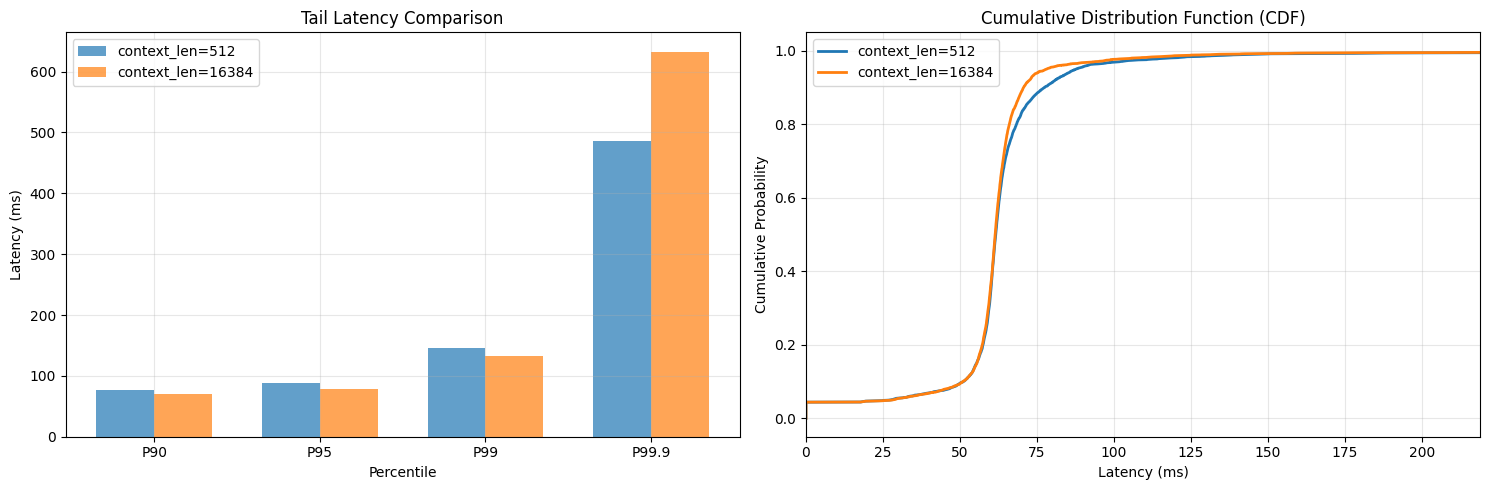

Dataset narrativeqa (200 requests) stats: 
*********************************************
Average input length: 31722.75, Average output length: 128.0
Max input length: 63872, Max output length: 128
Min input length: 9314, Min output length: 128
Median input length: 33460.0, Median output length: 128.0
*********************************************
Dataset dureader (200 requests) stats: 
*********************************************
Average input length: 10494.37, Average output length: 256.0
Average input length: 18881.37, Average output length: 256.0
max input length: 32000 min input length: 9589
Max input length: 18765, Max output length: 256
Min input length: 5327, Min output length: 256
Median input length: 10200.0, Median output length: 256.0
*********************************************
Dataset lsht (200 requests) stats: 
*********************************************
Average input length: 18302.69, Average output length: 128.0
Average input length: 22180.325, Average output length

In [81]:
# Load the two datasets for comparison
dataset_512_path = "/Users/yejie/Projects/SCS_Lab/IPDPS25_Scheduling/eval_results/ipdps25_sched/venilla_baseline_v0_8_4/default/logs_v1_Llama-3.1-8B_ofd0/burstgpt_offline/default_c32768_g-1_r5000_gp0.9_bt512_1_req_stats.csv"
dataset_8192_path = "/Users/yejie/Projects/SCS_Lab/IPDPS25_Scheduling/eval_results/ipdps25_sched/venilla_baseline_v0_8_4/default/logs_v1_Llama-3.1-8B_ofd0/burstgpt_offline/default_c32768_g-1_r5000_gp0.9_bt8192_1_req_stats.csv"
dataset_16384_path = "/Users/yejie/Projects/SCS_Lab/IPDPS25_Scheduling/eval_results/ipdps25_sched/venilla_baseline_v0_8_4/default/logs_v1_Llama-3.1-8B_ofd0/burstgpt_offline/default_c32768_g-1_r5000_gp0.9_bt16384_1_req_stats.csv"

data_512 = pd.read_csv(dataset_512_path)
data_8192 = pd.read_csv(dataset_8192_path)
data_16384 = pd.read_csv(dataset_16384_path)

# Sort both datasets by numeric request ID
for data in [data_512, data_8192, data_16384]:
    if "request_id" in data.columns:
        data['_numeric_id'] = data['request_id'].str.extract(r'(\d+)').astype(int)
        data.sort_values('_numeric_id', inplace=True)
        data.drop(columns=['_numeric_id'], inplace=True)
        data.reset_index(drop=True, inplace=True)

# Analyze tail latency comparison
print("Analyzing ITL (Inter-Token Latency) tail latency impact of context length...")
comparison_results = analyze_context_length_impact(data_8192, data_16384)


for dataset_name in ["narrativeqa", "dureader", "lsht"]:
# for dataset_name in ["sharegpt", "burstgpt", "azureconv", "multi_news", "gov_report", "narrativeqa"]:
    if dataset_name == "sharegpt" or dataset_name == "burstgpt":
        dataset_df_path = f"/Users/yejie/Projects/SCS_Lab/IPDPS25_Scheduling/eval_results/ipdps25_sched/venilla_baseline_v0_8_4/default/logs_v1_Llama-3.1-8B_ofd0/{dataset_name}_offline/default_c32768_g-1_r5000_gp0.9_bt16384_1_req_stats.csv"
        print(f"Dataset {dataset_name} (5000 requests) stats: ")
    elif dataset_name == "azureconv":
        dataset_df_path = f"/Users/yejie/Projects/SCS_Lab/IPDPS25_Scheduling/eval_results/ipdps25_sched/venilla_baseline_v0_8_4/default/logs_v1_Llama-3.1-8B_ofd0/{dataset_name}_offline/default_c32768_g-1_r10000_gp0.9_bt16384_1_req_stats.csv"
        print(f"Dataset {dataset_name} (10000 requests) stats: ")
    elif dataset_name == "narrativeqa":
        dataset_df_path = f"/Users/yejie/Projects/SCS_Lab/IPDPS25_Scheduling/eval_results/ipdps25_sched_test/venilla_baseline_v0_8_4/default/logs_v1_Yi-Coder-9B-Chat-8x-MoE_ofd0/longbench--{dataset_name}_offline/default_c65536_g128_r200_gp0.9_bt16384_1_req_stats.csv"
        print(f"Dataset {dataset_name} (200 requests) stats: ")
    elif dataset_name == "dureader":
        dataset_df_path = f"/Users/yejie/Projects/SCS_Lab/IPDPS25_Scheduling/eval_results/ipdps25_sched_test/venilla_baseline_v0_8_4/default/logs_v1_Yi-Coder-9B-Chat-8x-MoE_ofd0/longbench--{dataset_name}_offline/default_c65536_g256_r200_gp0.9_bt16384_1_req_stats.csv"
        print(f"Dataset {dataset_name} (200 requests) stats: ")
    elif dataset_name == "lsht":
        dataset_df_path = f"/Users/yejie/Projects/SCS_Lab/IPDPS25_Scheduling/eval_results/ipdps25_sched_test/venilla_baseline_v0_8_4/default/logs_v1_Llama-3.1-8B_ofd0/longbench--{dataset_name}_offline/default_c32768_g128_r200_gp0.9_bt16384_1_req_stats.csv"
        print(f"Dataset {dataset_name} (200 requests) stats: ")
    else:
        dataset_df_path = f"/Users/yejie/Projects/SCS_Lab/IPDPS25_Scheduling/eval_results/ipdps25_sched_test/venilla_baseline_v0_8_4/default/logs_v1_Llama-3.1-8B_ofd0/longbench--{dataset_name}_offline/default_c32768_g512_r200_gp0.9_bt16384_1_req_stats.csv"
        print(f"Dataset {dataset_name} (200 requests) stats: ")
    
    dataset_df = pd.read_csv(dataset_df_path)
    avg_input_len = dataset_df["num_prompt_tokens"].mean()
    max_input_len = dataset_df["num_prompt_tokens"].max()
    min_input_len = dataset_df["num_prompt_tokens"].min()
    median_input_len = dataset_df["num_prompt_tokens"].median()
    avg_output_len = dataset_df["num_gen_tokens"].mean()
    max_output_len = dataset_df["num_gen_tokens"].max()
    min_output_len = dataset_df["num_gen_tokens"].min()
    median_output_len = dataset_df["num_gen_tokens"].median()
    print(f"*********************************************")
    print(f"Average input length: {avg_input_len}, Average output length: {avg_output_len}")
    if dataset_name == "dureader":
        dataset_df["num_prompt_tokens"] = np.minimum(
                                                    np.ceil(dataset_df["num_prompt_tokens"] * 1.8).astype(int), 
                                                    32000
                                                )
        print(f"Average input length: {dataset_df["num_prompt_tokens"].mean()}, Average output length: {avg_output_len}")
        print(f"max input length: {dataset_df["num_prompt_tokens"].max()} min input length: {dataset_df["num_prompt_tokens"].min()}")
    if dataset_name == "lsht":
        dataset_df["num_prompt_tokens"] = np.minimum(
                                                    np.ceil(dataset_df["num_prompt_tokens"] * 1.25).astype(int), 
                                                    32000
                                                )
        print(f"Average input length: {dataset_df["num_prompt_tokens"].mean()}, Average output length: {avg_output_len}")
        print(f"max input length: {dataset_df["num_prompt_tokens"].max()} min input length: {dataset_df["num_prompt_tokens"].min()}")
    print(f"Max input length: {max_input_len}, Max output length: {max_output_len}")
    print(f"Min input length: {min_input_len}, Min output length: {min_output_len}")
    print(f"Median input length: {median_input_len}, Median output length: {median_output_len}")

    # plot_dataset_distribution(dataset_df, dataset_name)
    # plot_token_distribution(dataset_df, dataset_name, bins=500)

    

    print(f"*********************************************")

# # Usage example for BurstGPT
# burstgpt_path = "/Users/yejie/Projects/SCS_Lab/IPDPS25_Scheduling/eval_results/ipdps25_sched/venilla_baseline_v0_8_4/default/logs_v1_Llama-3.1-8B_ofd0/burstgpt_offline/default_c32768_g-1_r5000_gp0.9_bt512_1_req_stats.csv"

# # Load and plot BurstGPT data
# burstgpt_data = pd.read_csv(burstgpt_path)
# plot_token_distribution(burstgpt_data, "BurstGPT", bins=500)
    

In [72]:
def plot_scheduled_recomputed_tokens_histogram(sched_csv_path, title="Token Histogram Over Time", time_bin_seconds=5.0):
    """
    Create a histogram plot showing scheduled tokens and recomputed tokens over time.
    
    Args:
        sched_csv_path: Path to the scheduling statistics CSV file
        title: Title for the plot
        time_bin_seconds: Time bin size in seconds for aggregation
    """
    import pandas as pd
    import matplotlib.pyplot as plt
    import numpy as np
    
    # Read the scheduling statistics CSV
    df = pd.read_csv(sched_csv_path)
    
    # Extract the necessary columns
    if 'total_scheduled_tokens' not in df.columns or 'total_preempted_tokens' not in df.columns:
        raise ValueError("CSV must contain 'total_scheduled_tokens' and 'total_preempted_tokens' columns")
    
    # Calculate cumulative time from step duration
    if 'per_step_dur_ms' in df.columns:
        df['cumulative_time_s'] = df['per_step_dur_ms'].cumsum() / 1000.0
    elif 'exec_dur_ms' in df.columns:
        df['cumulative_time_s'] = df['exec_dur_ms'].cumsum() / 1000.0
    else:
        # Fallback: use step_id as time proxy
        df['cumulative_time_s'] = df['step_id'] * 1.0
    
    # Create time bins
    max_time = df['cumulative_time_s'].max()
    time_bins = np.arange(0, max_time + time_bin_seconds, time_bin_seconds)
    
    # Assign each step to a time bin
    df['time_bin'] = pd.cut(df['cumulative_time_s'], bins=time_bins, labels=time_bins[:-1], include_lowest=True)
    df['time_bin'] = df['time_bin'].astype(float)
    
    # Aggregate tokens by time bin
    binned_data = df.groupby('time_bin').agg({
        'total_scheduled_tokens': 'sum',
        'total_preempted_tokens': 'sum'
    }).reset_index()
    
    plt.rcParams['hatch.color'] = 'white'
    # Create the histogram plot
    fig, ax = plt.subplots(figsize=(8, 3))
    
    # Plot scheduled tokens as solid bars
    ax.bar(binned_data['time_bin'], binned_data['total_scheduled_tokens'] / 1000.0, 
           width=time_bin_seconds * 0.8, alpha=1, color='orange', 
           label='Scheduled Tokens', hatch='.', hatch_linewidth=0.2)
    
    # Plot recomputed tokens as hatched bars
    ax.bar(binned_data['time_bin'], binned_data['total_preempted_tokens'] / 1000.0, 
           width=time_bin_seconds * 0.8, alpha=0.75, color='green', 
           hatch='///', hatch_linewidth=0.2, label='Recomputed Tokens')
    
    # Add white dots for better visibility (similar to your reference image)
    # for i, row in binned_data.iterrows():
    #     if row['total_scheduled_tokens'] > 0:
    #         ax.scatter(row['time_bin'], row['total_scheduled_tokens'] / 1000.0, 
    #                   color='white', s=20, zorder=3)
    #     if row['total_preempted_tokens'] > 0:
    #         ax.scatter(row['time_bin'], row['total_preempted_tokens'] / 1000.0, 
    #                   color='white', s=20, zorder=3)
    
    # Formatting
    ax.set_xlabel('Time (seconds)')
    ax.set_ylabel('Num. of Tokens')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Set y-axis to show values in thousands (K)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.1f}K'))
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    total_scheduled = df['total_scheduled_tokens'].sum()
    total_recomputed = df['total_preempted_tokens'].sum()
    print(f"Total Scheduled Tokens: {total_scheduled:,}")
    print(f"Total Recomputed Tokens: {total_recomputed:,}")
    
    return binned_data


def plot_multiple_strategy_token_histogram(csv_paths_dict, title="Token Histogram Comparison", time_bin_seconds=1.0):
    """
    Create a comparison plot showing scheduled and recomputed tokens for multiple strategies.
    
    Args:
        csv_paths_dict: Dictionary with {strategy_name: csv_path} pairs
        title: Title for the plot
        time_bin_seconds: Time bin size in seconds for aggregation
    """
    import pandas as pd
    import matplotlib.pyplot as plt
    import numpy as np
    
    fig, axes = plt.subplots(len(csv_paths_dict), 1, figsize=(12, 4 * len(csv_paths_dict)))
    if len(csv_paths_dict) == 1:
        axes = [axes]
    
    colors = ['orange', 'green', 'blue', 'red', 'purple', 'brown']
    
    for idx, (strategy_name, csv_path) in enumerate(csv_paths_dict.items()):
        ax = axes[idx]
        
        # Read and process data
        df = pd.read_csv(csv_path)
        
        # Calculate cumulative time
        if 'per_step_dur_ms' in df.columns:
            df['cumulative_time_s'] = df['per_step_dur_ms'].cumsum() / 1000.0
        elif 'exec_dur_ms' in df.columns:
            df['cumulative_time_s'] = df['exec_dur_ms'].cumsum() / 1000.0
        else:
            df['cumulative_time_s'] = df['step_id'] * 1.0
        
        # Create time bins
        max_time = df['cumulative_time_s'].max()
        time_bins = np.arange(0, max_time + time_bin_seconds, time_bin_seconds)
        
        df['time_bin'] = pd.cut(df['cumulative_time_s'], bins=time_bins, labels=time_bins[:-1], include_lowest=True)
        df['time_bin'] = df['time_bin'].astype(float)
        
        # Aggregate tokens by time bin
        binned_data = df.groupby('time_bin').agg({
            'total_scheduled_tokens': 'sum',
            'total_preempted_tokens': 'sum'
        }).reset_index()
        
        # Plot
        ax.bar(binned_data['time_bin'], binned_data['total_scheduled_tokens'] / 1000.0, 
               width=time_bin_seconds * 0.8, alpha=0.7, color=colors[0], 
               label='Scheduled Tokens')
        
        ax.bar(binned_data['time_bin'], binned_data['total_preempted_tokens'] / 1000.0, 
               width=time_bin_seconds * 0.8, alpha=0.7, color=colors[1], 
               hatch='///', label='Recomputed Tokens')
        
        # Add white dots
        for i, row in binned_data.iterrows():
            if row['total_scheduled_tokens'] > 0:
                ax.scatter(row['time_bin'], row['total_scheduled_tokens'] / 1000.0, 
                          color='white', s=15, zorder=3)
            if row['total_preempted_tokens'] > 0:
                ax.scatter(row['time_bin'], row['total_preempted_tokens'] / 1000.0, 
                          color='white', s=15, zorder=3)
        
        # Formatting
        ax.set_xlabel('Time (seconds)')
        ax.set_ylabel('Num. of Tokens')
        ax.set_title(f'{strategy_name}')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.1f}K'))
        
        # Print statistics
        total_scheduled = df['total_scheduled_tokens'].sum()
        total_recomputed = df['total_preempted_tokens'].sum()
        print(f"{strategy_name} - Scheduled: {total_scheduled:,}, Recomputed: {total_recomputed:,}, Ratio: {total_recomputed/total_scheduled*100:.2f}%")
    
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


def analyze_csv_file(csv_path):
    """
    Analyze a CSV file to understand its structure and key metrics.
    """
    import pandas as pd
    
    df = pd.read_csv(csv_path)
    
    print(f"CSV File: {csv_path}")
    print(f"Shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
    
    if 'total_scheduled_tokens' in df.columns:
        print(f"Total Scheduled Tokens: {df['total_scheduled_tokens'].sum():,}")
    if 'total_preempted_tokens' in df.columns:
        print(f"Total Recomputed Tokens: {df['total_preempted_tokens'].sum():,}")


CSV File: /Users/yejie/Projects/SCS_Lab/IPDPS25_Scheduling/eval_results/ipdps25_sched/venilla_baseline_v0_8_4/default/logs_v1_Llama-3.1-8B_ofd0/longbench--narrativeqa_offline/default_c32768_g128_r200_gp0.9_bt8192_1_sched_stats.csv
Shape: (5239, 25)
Columns: ['step_id', 'sched_dur_ms', 'exec_dur_ms', 'output_dur_ms', 'per_step_dur_ms', 'lat_between_steps_ms', 'total_scheduled_tokens', 'total_scheduled_reqs', 'num_newly_scheduled', 'newly_scheduled_request_ids', 'num_running_requests', 'running_request_ids', 'num_preempted_requests', 'total_preempted_tokens', 'preempted_request_ids', 'preempted_tokens_by_request', 'num_resumed_requests', 'total_resumed_tokens', 'resumed_request_ids', 'resumed_tokens_by_request', 'kv_usage_before_sched', 'kv_usage_after_sched', 'kv_usage_after_process', 'est_avg_output_length', 'extras']
Total Scheduled Tokens: 19,065,789
Total Recomputed Tokens: 14,243,500


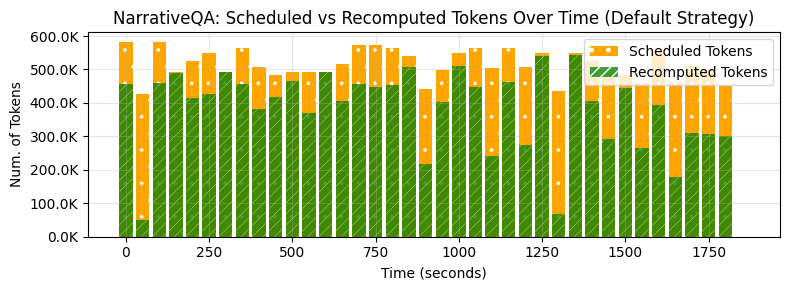

Total Scheduled Tokens: 19,065,789
Total Recomputed Tokens: 14,243,500


,time_bin,total_scheduled_tokens,total_preempted_tokens
0,0.00,581856,455112
1,50.00,426930,48834
2,100.00,581961,458418
3,150.00,491600,490818
4,200.00,524420,414340
5,250.00,549030,426756
6,300.00,491620,491220
7,350.00,565545,456023
8,400.00,508018,382120
9,450.00,483396,417588


In [73]:
# Example usage: Plot histogram for scheduled and recomputed tokens over time

# Single strategy example
sched_csv_path = "/Users/yejie/Projects/SCS_Lab/IPDPS25_Scheduling/eval_results/ipdps25_sched/venilla_baseline_v0_8_4/default/logs_v1_Llama-3.1-8B_ofd0/longbench--narrativeqa_offline/default_c32768_g128_r200_gp0.9_bt8192_1_sched_stats.csv"

# Analyze the CSV file first
analyze_csv_file(sched_csv_path)

# Create single strategy histogram
plot_scheduled_recomputed_tokens_histogram(
    sched_csv_path, 
    title="NarrativeQA: Scheduled vs Recomputed Tokens Over Time (Default Strategy)",
    time_bin_seconds=50
)


vllm-default - Scheduled: 19,065,789, Recomputed: 14,243,500, Ratio: 74.71%
our-approach - Scheduled: 4,822,289, Recomputed: 0, Ratio: 0.00%


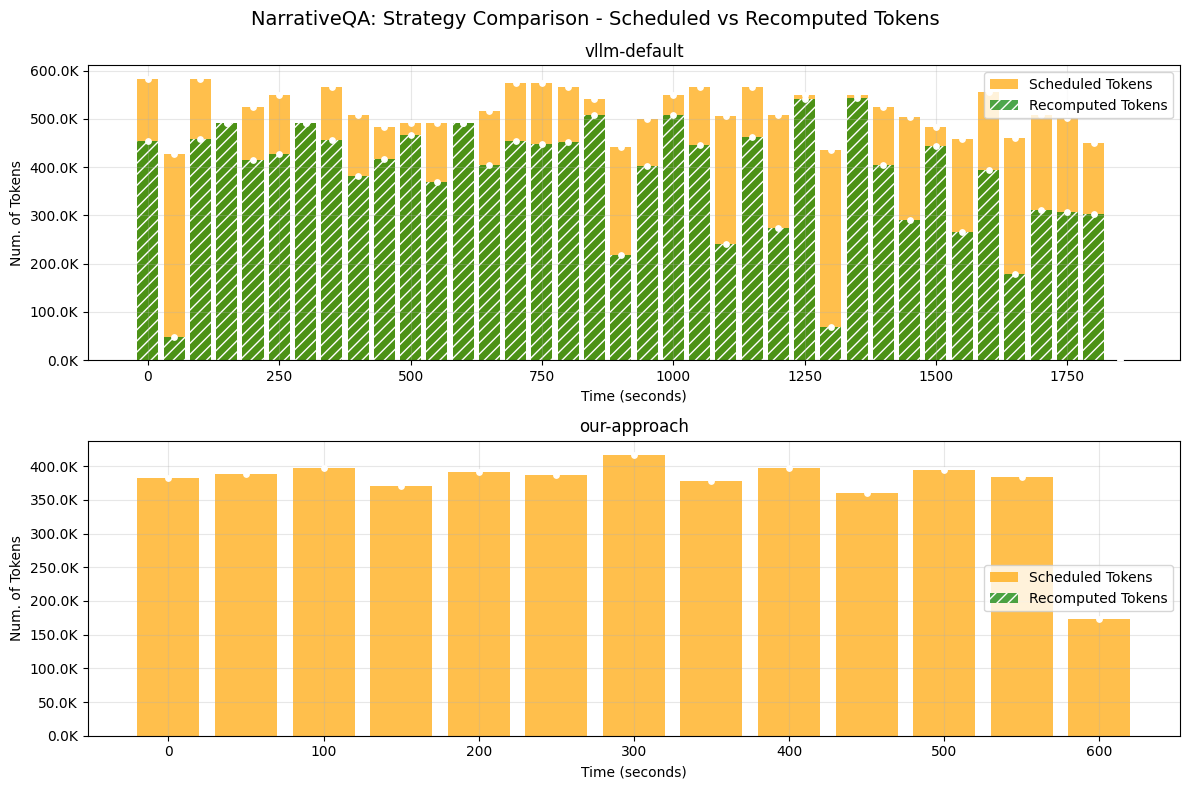

In [74]:
# Multiple strategy comparison example
base_dir = "/Users/yejie/Projects/SCS_Lab/IPDPS25_Scheduling/eval_results/ipdps25_sched/venilla_baseline_v0_8_4/"

csv_paths = {
    "vllm-default": f"{base_dir}/default/logs_v1_Llama-3.1-8B_ofd0/longbench--narrativeqa_offline/default_c32768_g128_r200_gp0.9_bt8192_1_sched_stats.csv",
    "our-approach": f"{base_dir}/evict-optimal-7/logs_v1_Llama-3.1-8B_ofd0/longbench--narrativeqa_offline/opt7_c32768_g128_r200_gp0.9_bt8192_1_sched_stats.csv"
}

# Create comparison plot
plot_multiple_strategy_token_histogram(
    csv_paths,
    title="NarrativeQA: Strategy Comparison - Scheduled vs Recomputed Tokens",
    time_bin_seconds=50
)
